<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

## Navigation
👉 Ouvrir : **Affichage → Table des matières** (sommaire cliquable généré automatiquement par Colab)


# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



# Etape 1 - Importation des librairies et chargement des fichiers


## 1.1 - Importation des librairies


In [2]:
# === Colab / Drive setup (exécution unique par session) ===
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
BASE_DIR = Path('/content/drive/MyDrive/OC_P6_Bottleneck')
RAW_DIR  = BASE_DIR / 'data_raw'
PROC_DIR = BASE_DIR / 'data_processed'
OUT_DIR  = BASE_DIR / 'outputs'

for d in [RAW_DIR, PROC_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ RAW_DIR :', RAW_DIR)
print('✅ PROC_DIR:', PROC_DIR)
print('✅ OUT_DIR :', OUT_DIR)

# Placer les 3 fichiers source (erp.xlsx, liaison.xlsx, web.xlsx) dans RAW_DIR.


Mounted at /content/drive
✅ RAW_DIR : /content/drive/MyDrive/OC_P6_Bottleneck/data_raw
✅ PROC_DIR: /content/drive/MyDrive/OC_P6_Bottleneck/data_processed
✅ OUT_DIR : /content/drive/MyDrive/OC_P6_Bottleneck/outputs


In [3]:
#Importation de la librairie Pandas
import pandas as pd

In [4]:
#Importation de la librairie plotly express
import plotly.express as px


In [5]:
#Afficher toutes les colonnes d'un dataframe dans l'affichage
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 0)


## 1.2 - Chargements des fichiers

In [6]:
#Importation des fichiers sources depuis Google Drive (RAW_DIR)
import pandas as pd
from google.colab import drive
from pathlib import Path
import pandas as pd

# Si RAW_DIR n'existe pas (nouvelle session), on (re)définit tout
try:
    RAW_DIR
except NameError:
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/OC_P6_Bottleneck')
    RAW_DIR  = BASE_DIR / 'data_raw'
    PROC_DIR = BASE_DIR / 'data_processed'
    OUT_DIR  = BASE_DIR / 'outputs'
    for d in [RAW_DIR, PROC_DIR, OUT_DIR]:
        d.mkdir(parents=True, exist_ok=True)

#Importation des 3 fichiers xlsx
expected = ['web.xlsx','erp.xlsx','liaison.xlsx']
missing = [f for f in expected if not (RAW_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Fichiers manquants dans {RAW_DIR} : {missing}. "
        "Dépose-les dans RAW_DIR (Google Drive) puis relance cette cellule."
    )

df_web = pd.read_excel(RAW_DIR / 'web.xlsx')
df_erp = pd.read_excel(RAW_DIR / 'erp.xlsx')
df_liaison = pd.read_excel(RAW_DIR / 'liaison.xlsx')

print('df_web    :', df_web.shape)
print('df_erp    :', df_erp.shape)
print('df_liaison:', df_liaison.shape)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


df_web    : (1513, 29)
df_erp    : (825, 6)
df_liaison: (825, 2)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [7]:
# === Helpers de sauvegarde / reprise (évite de rejouer tout le notebook) ===
def save_df(df, path):
    """Sauvegarde rapide et compacte."""
    df.to_parquet(path, index=False)

def load_df(path):
    return pd.read_parquet(path)

def load_or_build(path, builder_fn):
    """Charge le cache s'il existe, sinon construit puis sauvegarde."""
    if path.exists():
        print(f"✅ Cache chargé : {path.name}")
        return load_df(path)
    print(f"🛠️ Construction : {path.name}")
    df = builder_fn()
    save_df(df, path)
    print(f"💾 Cache écrit : {path.name}")
    return df


# Etape 2 - Analyse exploratoire des fichiers

## 2.1 - Analyse exploratoire du fichier erp.xlsx

In [8]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [9]:
#Consulter le nombre de colonnes
print("\nNombre de colonnes")
print("-" * 18)
print(df_erp.shape[1])

#La nature des données dans chacune des colonnes
print("\nTypes des colonnes")
print("-" * 16)
display(df_erp.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print("\nValeurs non nulles par colonne")
print("-" * 29)
display(df_erp.count())


Nombre de colonnes
------------------
6

Types des colonnes
----------------


,0
product_id,int64
onsale_web,int64
price,float64
stock_quantity,int64
stock_status,object
purchase_price,float64



Valeurs non nulles par colonne
-----------------------------


,0
product_id,825
onsale_web,825
price,825
stock_quantity,825
stock_status,825
purchase_price,825


In [10]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [11]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
nb_doublons = df_erp["product_id"].duplicated().sum()
print(f"Nombre de product_id en doublon : {nb_doublons}")

Nombre de product_id en doublon : 0


In [12]:
#Afficher les valeurs distinctes de la colonne stock_status
print("\nvaleurs distinctes de la colonne stock_status")
print("-" * 40)
vc = df_erp["stock_status"].value_counts(dropna=False)
total = vc.sum()
n = len(df_erp)
print(vc, "\n")
print(f"Total des statuts : {total} (sur {n} lignes) -> "
      f"{'✅ aucune valeur manquante dans stock_status' if total == n else '⚠️ valeurs manquantes détectées'}")


valeurs distinctes de la colonne stock_status
----------------------------------------
stock_status
instock       733
outofstock     92
Name: count, dtype: int64 

Total des statuts : 825 (sur 825 lignes) -> ✅ aucune valeur manquante dans stock_status


In [13]:
#À quelle(s) autre(s) colonne(s) sont-elles liées ?

#Cohérence stock_status ↔ stock_quantity
En règle générale :  
- `instock` devrait correspondre à une quantité > 0  
- `outofstock` devrait correspondre à une quantité = 0  
On vérifie donc les incohérences possibles.


In [14]:
print("instock avec quantité <= 0 :",
      ((df_erp["stock_status"]=="instock") & (df_erp["stock_quantity"]<=0)).sum())

print("outofstock avec quantité > 0 :",
      ((df_erp["stock_status"]=="outofstock") & (df_erp["stock_quantity"]>0)).sum())


instock avec quantité <= 0 : 1
outofstock avec quantité > 0 : 1


#Stock_status et mise en vente sur le web (onsale_web)
On observe si les produits `instock/outofstock` sont majoritairement marqués comme vendus sur le site.
Ce n’est pas une règle stricte, mais cela donne un premier aperçu.


In [15]:
pd.crosstab(df_erp["stock_status"], df_erp["onsale_web"])


onsale_web,0,1
stock_status,,
instock,65,668
outofstock,44,48


Instock : 668 produits sont vendus sur le web (onsale_web=1) contre 65 non vendus (onsale_web=0).
👉 Logique : la majorité des produits en stock sont bien commercialisés en ligne.

Outofstock : 48 produits sont vendus sur le web malgré un statut en rupture, contre 44 non vendus.
👉 Là, c’est intéressant : une part importante des produits en rupture reste publiée/vendable sur le site.

In [16]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"

import numpy as np

df_erp["stock_status_2"] = np.where(df_erp["stock_quantity"] == 0, "outofstock", "instock")
df_erp[["stock_quantity", "stock_status", "stock_status_2"]].head()


,stock_quantity,stock_status,stock_status_2
0,16,instock,instock
1,10,instock,instock
2,0,outofstock,outofstock
3,26,instock,instock
4,3,outofstock,instock


In [17]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [18]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset => FAUX.

eq = df_erp["stock_status"] == df_erp["stock_status_2"]
print("Nombre de lignes cohérentes :", eq.sum())
print("Nombre de lignes total :", len(df_erp))
print("Nombre de lignes incohérentes :", len(df_erp) - eq.sum())


Nombre de lignes cohérentes : 821
Nombre de lignes total : 825
Nombre de lignes incohérentes : 4


In [19]:
pd.crosstab(df_erp["stock_status"], df_erp["stock_status_2"])


stock_status_2,instock,outofstock
stock_status,,
instock,732,1
outofstock,3,89


Si stock_status était parfaitement cohérent avec stock_quantity, on obtiendrait une somme égale au nombre total de lignes (825). Ici, la somme vaut 821 : cela indique 4 incohérences à investiguer.

In [20]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [21]:
eq = df_erp["stock_status"]==(df_erp["stock_status_2"])

df_erp.loc[~eq, ["product_id","stock_quantity","stock_status","stock_status_2"]].sort_values("product_id")

,product_id,stock_quantity,stock_status,stock_status_2
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock
449,4973,-10,outofstock,instock
573,5700,-1,outofstock,instock


In [22]:
#Corriger la ou les données incohérentes

df_erp.loc[~eq, "stock_status"] = df_erp.loc[~eq, "stock_status_2"]


In [23]:
#Vérification en utilisant le même code que plus haut pour afficher les problèmes

eq = df_erp["stock_status"]==(df_erp["stock_status_2"])

print("Nombre de lignes cohérentes :", eq.sum())
print("Nombre de lignes total :", len(df_erp))
print("Nombre de lignes incohérentes :", len(df_erp) - eq.sum())

df_erp.loc[~eq, ["product_id","stock_quantity","stock_status","stock_status_2"]]


Nombre de lignes cohérentes : 825
Nombre de lignes total : 825
Nombre de lignes incohérentes : 0


,product_id,stock_quantity,stock_status,stock_status_2


In [24]:
# df_erp avec colonne techniquen'stock_status_2
print ("\ndf_erp avec colonne 'stock_status_2'")
display(df_erp.head())
print(""*100)
print("-"*100)

# Nettoyage : on supprime la colonne technique si elle existe
if "stock_status_2" in df_erp.columns:
    df_erp = df_erp.drop(columns=["stock_status_2"])

# Sauvegarde du fichier avec la colonne 'stock_status' corrigée
erp_clean_path = PROC_DIR / "erp_clean.parquet"
save_df(df_erp, erp_clean_path)
print(f"✅ ERP corrigé (sans colonne technique stock_status_2 sauvegardé : {erp_clean_path}")

print(""*100)
print("-"*100)
print("\ndf_erp sans colonne 'stock_status_2'")
display(df_erp.head())


df_erp avec colonne 'stock_status_2'


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock



----------------------------------------------------------------------------------------------------
✅ ERP corrigé (sans colonne technique stock_status_2 sauvegardé : /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/erp_clean.parquet

----------------------------------------------------------------------------------------------------

df_erp sans colonne 'stock_status_2'


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


Nous avons corrigé les incohérences stock_status ↔ stock_quantity. La colonne technique stock_status_2 a servi au contrôle puis a été supprimée du dataset clean. Le fichier erp_clean.parquet est utilisé comme point de reprise pour la suite.

### 2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx

In [25]:
# Rechargement df_erp corrigé sans colonne technique 'stock_status_2'
erp_clean_path = PROC_DIR / "erp_clean.parquet"

if erp_clean_path.exists():
    df_erp = load_df(erp_clean_path)
    print("✅ df_erp rechargé depuis erp_clean.parquet (version corrigée)")
else:
    print("⚠️ erp_clean.parquet introuvable : df_erp reste la version brute chargée depuis erp.xlsx")


✅ df_erp rechargé depuis erp_clean.parquet (version corrigée)


In [26]:
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


#### 2.1.1.1 - Analyse de la variable PRIX

In [27]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isna().sum()))
print(""*100)
print("-"*100)

#Afficher le prix minimum de la colonne "price"
print("Prix minimum: {}".format(df_erp["price"].min()))
print(""*100)
print("-"*100)

#Afficher le prix maximum de la colonne "price"
print("Prix maximum: {}".format(df_erp["price"].max()))
print(""*100)
print("-"*100)

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_anormaux = df_erp[df_erp["price"] <= 0]
print("Nombre de prix <= 0 :", prix_anormaux.shape[0])
display(prix_anormaux)


Nombres d'articles avec un prix non renseigné: 0

----------------------------------------------------------------------------------------------------
Prix minimum: -20.0

----------------------------------------------------------------------------------------------------
Prix maximum: 225.0

----------------------------------------------------------------------------------------------------
Nombre de prix <= 0 : 3


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
469,5017,0,-8.0,0,outofstock,4.34
739,6594,0,-9.1,19,instock,4.61


Aucun prix manquant n’est observé. En revanche, 3 produits présentent un prix négatif (min = -20), ce qui constitue une anomalie de qualité des données. Ces lignes seront isolées/flagguées et exclues des calculs de performance (CA, marge) afin de ne pas biaiser l’analyse.

In [28]:
# Création colonne "flag_price_anomaly"
df_erp["flag_price_anomaly"] = df_erp["price"].isna() | (df_erp["price"] <= 0)
display(df_erp.head())
print(""*100)
print("-"*100)

print("Nb anomalies de prix (<=0 ou NaN) :", df_erp["flag_price_anomaly"].sum())
print(""*100)
print("-"*100)

# Liste des produits concernés
print("\nListe des produits concerés")
display(df_erp.loc[df_erp["flag_price_anomaly"],
                   ["flag_price_anomaly","product_id","onsale_web","price","purchase_price","stock_quantity","stock_status"]])


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,flag_price_anomaly
0,3847,1,24.2,16,instock,12.88,False
1,3849,1,34.3,10,instock,17.54,False
2,3850,1,20.8,0,outofstock,10.64,False
3,4032,1,14.1,26,instock,6.92,False
4,4039,1,46.0,3,instock,23.77,False



----------------------------------------------------------------------------------------------------
Nb anomalies de prix (<=0 ou NaN) : 3

----------------------------------------------------------------------------------------------------

Liste des produits concerés


,flag_price_anomaly,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status
151,True,4233,0,-20.0,10.33,0,outofstock
469,True,5017,0,-8.0,4.34,0,outofstock
739,True,6594,0,-9.1,4.61,19,instock


In [29]:
# Création d'une copie et d'une sauvegarde du DataFrame avec les prix valides *df_erp_valid_price*
df_erp_valid_price = df_erp.loc[~df_erp["flag_price_anomaly"]].copy()
print("\nNombre de lignes et colonnes de 'df_erp_valid_price'")
display(df_erp_valid_price.shape)

# Vérifications
print("Prix <= 0 restants :", (df_erp_valid_price["price"] <= 0).sum())
print("Prix manquants restants :", df_erp_valid_price["price"].isna().sum())

# Sauvegarde df_erp_valid_price
save_df(df_erp_valid_price, PROC_DIR / "erp_valid_price.parquet")



Nombre de lignes et colonnes de 'df_erp_valid_price'


(822, 7)

Prix <= 0 restants : 0
Prix manquants restants : 0


Les 3 produits avec prix ≤ 0 sont flaggués et exclus des analyses de CA/marge afin de ne pas biaiser les indicateurs.

#### 2.1.1.2 - Analyse de la variable STOCK

In [30]:
#######################
### stock_quantity  ###
#######################

# Quantité minimum / maximum
print("Stock minimum :", df_erp["stock_quantity"].min())
print("Stock maximum :", df_erp["stock_quantity"].max())

# Stocks négatifs (anomalies)
stock_negatif = df_erp[df_erp["stock_quantity"] < 0]
print("Nombre de stocks < 0 :", stock_negatif.shape[0])

if stock_negatif.shape[0] > 0:
    display(stock_negatif[["product_id","onsale_web","stock_quantity","stock_status","price","purchase_price"]])



Stock minimum : -10
Stock maximum : 145
Nombre de stocks < 0 : 2


,product_id,onsale_web,stock_quantity,stock_status,price,purchase_price
449,4973,0,-10,instock,10.0,4.96
573,5700,1,-1,instock,44.5,22.30


### Traitement des stocks négatifs
Les valeurs de `stock_quantity` strictement négatives sont considérées comme des anomalies de qualité (erreur de saisie, décalage d’inventaire, mouvement de stock non enregistré, etc.).  
Afin de ne pas biaiser les indicateurs liés au stock (rotation, mois de stock, valorisation), nous ne corrigeons pas arbitrairement ces lignes : nous les **flagguons**, les **listons pour investigation**, puis les **excluons** des analyses de stock tout en conservant la trace des anomalies.


In [31]:
# Liste des produits concernés
df_erp["flag_stock_anomaly"] = df_erp["stock_quantity"] < 0
print("\nListe des produits concernés par les stocks négatifs")
display(df_erp.loc[df_erp["flag_stock_anomaly"],
                   ["flag_stock_anomaly","product_id","onsale_web","price","purchase_price","stock_quantity","stock_status"]])

# Création d'une copie et d'une sauvegarde du DataFrame avec les stocks valides *df_erp_valid_stock*
df_erp_valid_stock = df_erp.loc[~df_erp["flag_stock_anomaly"]].copy()
print("\nNombre de lignes et colonnes de 'df_erp_valid_stock'")
display(df_erp_valid_stock.shape)

# Vérifications
print("Stocks négatifs restants :", (df_erp_valid_stock["stock_quantity"] < 0).sum())
print("Stocks manquants restants :", df_erp_valid_stock["stock_quantity"].isna().sum())

# Sauvegarde df_erp_valid_price
save_df(df_erp_valid_stock, PROC_DIR / "erp_valid_stock.parquet")


Liste des produits concernés par les stocks négatifs


,flag_stock_anomaly,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status
449,True,4973,0,10.0,4.96,-10,instock
573,True,5700,1,44.5,22.30,-1,instock



Nombre de lignes et colonnes de 'df_erp_valid_stock'


(823, 8)

Stocks négatifs restants : 0
Stocks manquants restants : 0


#### 2.1.1.3 - Analyse de la variable ONSALE_WEB

In [32]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?

# Valeurs distinctes + effectifs
print("Valeurs distinctes de onsale_web :", df_erp["onsale_web"].unique())
display(df_erp["onsale_web"].value_counts(dropna=False))

# Vérification : binaire attendu {0,1}
valeurs_attendues = {0, 1}
valeurs_reelles = set(df_erp["onsale_web"].dropna().unique())
print("Binaire conforme ? ->", valeurs_reelles.issubset(valeurs_attendues))



Valeurs distinctes de onsale_web : [1 0]


,count
onsale_web,
1,716
0,109


Binaire conforme ? -> True


In [33]:
pd.crosstab(df_erp["onsale_web"], df_erp["stock_status"])


stock_status,instock,outofstock
onsale_web,,
0,66,43
1,669,47


Le croisement onsale_web × stock_status montre que la plupart des références sont destinées au canal web (716/825). On observe toutefois 47 produits publiés sur le web alors qu’ils sont en rupture, et 66 produits en stock non publiés : ces cas méritent une vérification des règles de publication et de mise à jour des stocks afin d’éviter des incohérences de pilotage

In [34]:
# Liste des 47 produits “web + rupture”
print("\nListe des 47 produits 'web + rupture'")
df_erp.loc[(df_erp["onsale_web"]==1) & (df_erp["stock_status"]=="outofstock"),
           ["onsale_web","product_id","stock_quantity","stock_status","price","purchase_price"]]


Liste des 47 produits 'web + rupture'


,onsale_web,product_id,stock_quantity,stock_status,price,purchase_price
2,1,3850,0,outofstock,20.80,10.64
8,1,4043,0,outofstock,60.00,29.45
11,1,4047,0,outofstock,18.30,9.93
15,1,4051,0,outofstock,7.70,4.14
16,1,4052,0,outofstock,33.70,18.11
28,1,4065,0,outofstock,19.50,9.67
42,1,4079,0,outofstock,37.00,19.50
57,1,4100,0,outofstock,15.80,8.57
70,1,4138,0,outofstock,25.70,13.01
106,1,4179,0,outofstock,24.00,13.02


In [35]:
#Quelles sont les colonnes à conserver selon vous?


### Colonnes à conserver

Pour la suite du projet, je conserve uniquement les colonnes “métier” nécessaires au rapprochement ERP ↔ Web et aux analyses (CA, marge, stock) :

- `product_id` : identifiant produit côté ERP (clé de jointure avec la table de liaison)
- `onsale_web` : indicateur de mise en vente sur le site (segmentation web / hors web)
- `price` : prix de vente (base des calculs de CA)
- `purchase_price` : prix d’achat (base des calculs de marge)
- `stock_quantity` : quantité en stock (rotation, mois de stock, contrôles)
- `stock_status` : statut de stock (corrigé à partir de `stock_quantity`)

Les colonnes techniques utilisées uniquement pour le contrôle (ex. `stock_status_2`) ne sont pas conservées dans le dataset final afin de garder un jeu de données propre.  
Les éventuels indicateurs de qualité (colonnes de type `flag_*`) peuvent être conservés dans un fichier “audit” séparé pour documenter les anomalies, sans alourdir le dataset principal.


In [36]:
# Comment se présente le fichier df_erp à ce stade
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,flag_price_anomaly,flag_stock_anomaly
0,3847,1,24.2,16,instock,12.88,False,False
1,3849,1,34.3,10,instock,17.54,False,False
2,3850,1,20.8,0,outofstock,10.64,False,False
3,4032,1,14.1,26,instock,6.92,False,False
4,4039,1,46.0,3,instock,23.77,False,False


In [37]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".


*   **La colonne "stock_status_2" a déjà été supprimée** au terme de l'étape 2.1. Analyse exploratoire du fichier erp.

*   Nous avions créé les 2 colonnes permettant de filtrer les anomalies sur les prix et les stocks ('flag_price_anomaly' et 'flag_stock_anomaly').

*   Remarque : durant la phase de contrôle qualité, des colonnes techniques (ex. `flag_*`) peuvent être ajoutées temporairement pour identifier et tracer les anomalies.

*   Ces colonnes ne font pas partie du jeu de données final : elles seront conservées dans un fichier “audit”, tandis que le dataset “analysis” ne conserve que les colonnes métier listées ci-dessus.








#### 2.1.1.4 - Analyse de la variable prix d'achat

In [38]:
#######################
##  prix d'achat     ##
#######################

# 1) Prix d'achat non renseignés (NaN)
nb_na = df_erp["purchase_price"].isna().sum()
print("Nombre d'articles avec un prix d'achat non renseigné :", nb_na)

if nb_na > 0:
    display(df_erp.loc[df_erp["purchase_price"].isna(),
                       ["product_id","purchase_price","price","onsale_web","stock_quantity","stock_status"]])

# 2) Min / Max
print("Prix d'achat minimum :", df_erp["purchase_price"].min())
print("Prix d'achat maximum :", df_erp["purchase_price"].max())

# Bonus recommandé : valeurs <= 0 (anomalies probables)
pp_anormaux = df_erp[df_erp["purchase_price"] <= 0]
print("Nombre de prix d'achat <= 0 :", len(pp_anormaux))

if len(pp_anormaux) > 0:
    display(pp_anormaux[["product_id","purchase_price","price","onsale_web","stock_quantity","stock_status"]])



Nombre d'articles avec un prix d'achat non renseigné : 0
Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81
Nombre de prix d'achat <= 0 : 0


### Conclusion – purchase_price
Aucune valeur manquante n’est constatée sur `purchase_price` et aucune valeur n’est ≤ 0.  
Le prix d’achat varie de 2,74 à 137,81 : la variable est exploitable telle quelle pour les analyses de marge.


#### 2.1.1.5 - Sauvegarde des Dataset ERP Audit et Analysis

**Dataset Audit**

In [39]:
df_erp_audit = df_erp.copy()

**Dataset final (colonnes métier uniquement + filtrage des anomalies)**
### Construction du jeu de données ERP “analysis”

À ce stade, `df_erp` contient les colonnes métier ainsi que des indicateurs de qualité (`flag_*`) utilisés pour identifier les anomalies (prix ≤ 0, stocks négatifs, etc.).  
Pour la suite des analyses (CA, marge, rotation des stocks) et les jointures avec les données Web, nous construisons un jeu de données “analysis” filtré des anomalies, ne conservant que les colonnes métier nécessaires.

In [40]:
cols_keep = ["product_id","onsale_web","price","purchase_price","stock_quantity","stock_status"]

mask_ok = (~df_erp["flag_price_anomaly"].fillna(False)) & (~df_erp["flag_stock_anomaly"].fillna(False))

df_erp_analysis = df_erp.loc[mask_ok, cols_keep].copy()

display(df_erp_analysis.head())

df_erp_analysis.shape

,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status
0,3847,1,24.2,12.88,16,instock
1,3849,1,34.3,17.54,10,instock
2,3850,1,20.8,10.64,0,outofstock
3,4032,1,14.1,6.92,26,instock
4,4039,1,46.0,23.77,3,instock


(820, 6)

**Le fichier df_erp, qui au départ comptait 825 lignes, est ainsi expurgé des 3 prix négatifs (-20, -8 et -9.1) et des 2 stocks négatifs (-10 et -1).**

**Sauvegarde erp_audit et erp_analysis**

In [41]:
# Sauvegarde audit (avec flags) - traçabilité
save_df(df_erp, PROC_DIR / "erp_audit.parquet")

# Sauvegarde analysis (sans flags) - base pour la suite
save_df(df_erp_analysis, PROC_DIR / "erp_analysis.parquet")

print("✅ Sauvegardes OK : erp_audit.parquet + erp_analysis.parquet")

✅ Sauvegardes OK : erp_audit.parquet + erp_analysis.parquet


## 2.2 - Analyse exploratoire du fichier web.xlsx


### 2.2.1 - Aperçu et caractéristiques du fichier df_web

In [42]:
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [43]:
print("=== WEB : Dimensions du dataset ===\n")
print(f"• Dimension (lignes, colonnes) : {df_web.shape}")
print(f"• Nombre d'observations : {df_web.shape[0]}")
print(f"• Nombre de caractéristiques : {df_web.shape[1]}")



=== WEB : Dimensions du dataset ===

• Dimension (lignes, colonnes) : (1513, 29)
• Nombre d'observations : 1513
• Nombre de caractéristiques : 29


In [44]:
# Nombre de colonnes
print("Nb colonnes :", df_web.shape[1])

# Nature des données dans chaque colonne
print("\nNature des données dans chacune des colonnes :")
display(df_web.dtypes)

# Nombre de valeurs présentes (non null) dans chaque colonne
print("\nNombre de valeurs présentes dans chacune des colonnes :")
display(df_web.count())


Nb colonnes : 29

Nature des données dans chacune des colonnes :


,0
sku,object
virtual,int64
downloadable,int64
rating_count,int64
average_rating,float64
total_sales,float64
tax_status,object
tax_class,float64
post_author,float64
post_date,datetime64[ns]



Nombre de valeurs présentes dans chacune des colonnes :


,0
sku,1428
virtual,1513
downloadable,1513
rating_count,1513
average_rating,1430
total_sales,1430
tax_status,716
tax_class,0
post_author,1430
post_date,1430


*   df_web a 29 colonnes et 1513 lignes.

*   Plusieurs colonnes sont massivement incomplètes :
*     100% vides : tax_class, post_content, post_password, post_content_filtered (count = 0)
*     Très incomplètes : tax_status (716/1513), post_excerpt (716/1513), post_mime_type (714/1513)
*     sku n’est pas renseigné partout : 1428/1513 → 85 lignes sans SKU (cela pose un gros sujet de jointure).

*  Beaucoup de champs WordPress “techniques” (post_*, guid, menu_order, etc.) ne servent pas forcément à l’analyse métier.




### 2.2.2 - Normalisation de SKU

In [45]:
# Normalisation SKU : on force en texte + on nettoie
df_web["sku_clean"] = (
    df_web["sku"]
    .astype("string")          # évite le mix int/str
    .str.strip()               # enlève espaces
)

# Remplace les chaînes vides par NA
df_web.loc[df_web["sku_clean"].isin(["", "nan", "None"]), "sku_clean"] = pd.NA

print("SKU_clean manquants :", df_web["sku_clean"].isna().sum())
print("Doublons SKU_clean :", df_web["sku_clean"].duplicated().sum())


SKU_clean manquants : 85
Doublons SKU_clean : 798


In [46]:
# === Contrôle qualité SKU (après création de sku_clean) ===

n_total = len(df_web)
n_na = df_web["sku_clean"].isna().sum()

# duplicated() compte aussi les NA comme "doublons" à partir du 2ème NA
dup_total = df_web["sku_clean"].duplicated().sum()

# Doublons uniquement sur les SKU renseignés (hors NA)
dup_non_null = df_web.loc[df_web["sku_clean"].notna(), "sku_clean"].duplicated().sum()

# Doublons "dus" aux NA (si n_na >= 1 alors il y a n_na-1 doublons NA)
dup_na = max(n_na - 1, 0)

# Nombre de SKU distincts (hors NA)
n_unique_non_null = df_web["sku_clean"].nunique(dropna=True)

print("=== Diagnostic sku_clean ===")
print(f"Nb lignes total               : {n_total}")
print(f"SKU_clean manquants (NA)      : {n_na}")
print(f"Doublons sku_clean (total)    : {dup_total}")
print(f"  dont doublons hors NA       : {dup_non_null}")
print(f"  dont doublons 'NA'          : {dup_na}")
print(f"SKU distincts (hors NA)       : {n_unique_non_null}")

# Optionnel : cohérence arithmétique
print("\nCheck :", dup_total, "=", dup_non_null, "+", dup_na, "->", dup_non_null + dup_na)



=== Diagnostic sku_clean ===
Nb lignes total               : 1513
SKU_clean manquants (NA)      : 85
Doublons sku_clean (total)    : 798
  dont doublons hors NA       : 714
  dont doublons 'NA'          : 84
SKU distincts (hors NA)       : 714

Check : 798 = 714 + 84 -> 798


In [47]:
# Afficher les sku dupliqués
dup = df_web["sku_clean"].duplicated(keep=False)

df_dup = df_web.loc[dup, ["sku_clean","sku","post_title","post_type","product_type","post_status","post_date"]]
display(df_dup.sort_values("sku_clean").head(20))  # limiter l'affichage à 20


,sku_clean,sku,post_title,post_type,product_type,post_status,post_date
668,10014,10014,Darnley's London Dry Gin Original,product,Gin,publish,2019-04-04 15:45:23
1030,10014,10014,Darnley's London Dry Gin Original,attachment,Gin,publish,2019-04-04 15:45:23
887,10459,10459,Alphonse Mellot Sancerre Rouge Génération XIX ...,attachment,Vin,publish,2018-04-13 15:58:19
748,10459,10459,Alphonse Mellot Sancerre Rouge Génération XIX ...,product,Vin,publish,2018-04-13 15:58:19
802,10775,10775,Albert Mann Pinot Gris Vendanges Tardives Alte...,product,Vin,publish,2018-04-17 21:28:52
1317,10775,10775,Albert Mann Pinot Gris Vendanges Tardives Alte...,attachment,Vin,publish,2018-04-17 21:28:52
520,10814,10814,Thierry Germain Saumur-Champigny Outre Terre 2013,attachment,Vin,publish,2018-04-17 10:12:40
860,10814,10814,Thierry Germain Saumur-Champigny Outre Terre 2013,product,Vin,publish,2018-04-17 10:12:40
1322,11049,11049,Alphonse Mellot Sancerre Rouge En Grands Champ...,attachment,Vin,publish,2018-04-13 16:07:49
408,11049,11049,Alphonse Mellot Sancerre Rouge En Grands Champ...,product,Vin,publish,2018-04-13 16:07:49


### 2.2.3 - Diagnostics structurants sur web.xlsx (identifier le périmètre “produit”)

Le fichier `web.xlsx` provient de l’environnement WordPress/WooCommerce et contient un mélange de données métier (SKU, ventes, notes, catégories) et de données techniques WordPress (`post_*`, `guid`, etc.).  
Avant toute jointure avec l’ERP, il est indispensable de comprendre **quels types d’objets** sont présents dans l’export et d’identifier le **périmètre réellement exploitable** pour l’analyse produit.

La démarche est la suivante :

1. **Sécuriser la clé fonctionnelle côté web** : normaliser `sku` (en texte) et mesurer sa complétude / unicité.  
2. **Identifier les objets non-produits** susceptibles de créer des doublons (ex. médias WordPress) via `post_type`.  
3. **Vérifier l’état de publication** via `post_status` (produits publiés vs brouillons/archives).  
4. **Qualifier le périmètre métier** via `product_type` qui, dans ce dataset, correspond à une **catégorie produit** (ex. Vin, Gin, Champagne) et non au type technique WooCommerce.

Ces diagnostics permettent de définir une règle de filtrage/déduplication défendable avant le rapprochement avec l’ERP via la table de liaison.


In [48]:
# ----------------------------
# Diagnostics structurants WEB
# ----------------------------

# 1) Composition du fichier : types d'objets WordPress
print("=== Répartition post_type (types d'objets) ===")
display(df_web["post_type"].value_counts(dropna=False))

# 2) Statut de publication : publié vs brouillon/archives
print("\n=== Répartition post_status (statut de publication) ===")
display(df_web["post_status"].value_counts(dropna=False))

# 3) Catégories métier (dans ce dataset, product_type = typologie produit)
print("\n=== Répartition product_type (catégories produit) ===")
display(df_web["product_type"].value_counts(dropna=False).head(30))

# 4) Contrôle clé : complétude et unicité du SKU normalisé
print("\n=== Qualité de la clé SKU (sku_clean) ===")
print("SKU_clean manquants :", df_web["sku_clean"].isna().sum())
print("Doublons SKU_clean :", df_web["sku_clean"].duplicated().sum())


=== Répartition post_type (types d'objets) ===


,count
post_type,
product,716
attachment,714
NaN,83



=== Répartition post_status (statut de publication) ===


,count
post_status,
publish,1430
NaN,83



=== Répartition product_type (catégories produit) ===


,count
product_type,
Vin,1318
NaN,84
Champagne,56
Whisky,28
Cognac,16
Huile d'olive,6
Gin,4
Autre,1



=== Qualité de la clé SKU (sku_clean) ===
SKU_clean manquants : 85
Doublons SKU_clean : 798


In [49]:
# Synthèse SKU
# ------------------------

n_rows = len(df_web)

# SKU manquants
n_na = df_web["sku_clean"].isna().sum()

# Doublons au sens "lignes en trop" (keep=first)
n_dup_excess = df_web["sku_clean"].duplicated(keep="first").sum()

# Doublons au sens "toutes les lignes concernées par une clé non unique"
mask_dup_all = df_web["sku_clean"].duplicated(keep=False)
n_dup_all_rows = mask_dup_all.sum()

# Nombre de clés distinctes (en comptant NA comme une valeur si présent)
n_unique_keys = df_web["sku_clean"].nunique(dropna=False)

print("=== Synthèse SKU ===")
print(f"Lignes totales                : {n_rows}")
print(f"SKU_clean manquants (NA)      : {n_na}")
print(f"Clés sku_clean distinctes     : {n_unique_keys}")
print(f"Doublons (lignes en trop)     : {n_dup_excess}   (duplicated keep='first')")
print(f"Lignes concernées par doublons: {n_dup_all_rows} (duplicated keep=False)")

print("\n=== Répartition post_type sur les lignes concernées (keep=False) ===")
display(df_web.loc[mask_dup_all, "post_type"].value_counts(dropna=False))

print("\n=== Répartition post_type sur les 'lignes en trop' (keep='first') ===")
display(df_web.loc[df_web["sku_clean"].duplicated(keep="first"), "post_type"].value_counts(dropna=False))


=== Synthèse SKU ===
Lignes totales                : 1513
SKU_clean manquants (NA)      : 85
Clés sku_clean distinctes     : 715
Doublons (lignes en trop)     : 798   (duplicated keep='first')
Lignes concernées par doublons: 1513 (duplicated keep=False)

=== Répartition post_type sur les lignes concernées (keep=False) ===


,count
post_type,
product,716
attachment,714
NaN,83



=== Répartition post_type sur les 'lignes en trop' (keep='first') ===


,count
post_type,
attachment,361
product,355
NaN,82


### 2.2.4 - Construire le périmètre produits

In [50]:
# Périmètre exploitable : uniquement les produits (on exclut les médias WordPress)
df_web_products = df_web.loc[df_web["post_type"]==("product")].copy()

print("Lignes web total :", len(df_web))
print("Lignes web produits :", len(df_web_products))
print("SKU_clean manquants (produits) :", df_web_products["sku_clean"].isna().sum())

# Unicité sur les SKU renseignés (vrai test de doublons)
sku_non_null = df_web_products["sku_clean"].dropna()
print("Doublons SKU_clean (produits, hors NA) :", sku_non_null.duplicated().sum())


Lignes web total : 1513
Lignes web produits : 716
SKU_clean manquants (produits) : 2
Doublons SKU_clean (produits, hors NA) : 0


Les “798 doublons” étaient un effet WordPress (attachments), pas un problème produit.

### Lignes sans code article (SKU manquant)
Objectif : comprendre **pourquoi** 85 lignes n’ont pas de SKU, et distinguer :
- les lignes **hors périmètre produit** (objets WordPress techniques : attachments, lignes vides, etc.)
- les **vrais produits** sans SKU (problème de qualité de donnée, bloquant pour la jointure)


In [51]:
# 1) Toutes les lignes sans SKU_clean (tous objets WordPress)
df_web_no_sku = df_web[df_web["sku_clean"].isna()].copy()
print(f"Nb lignes sans SKU_clean (global) : {len(df_web_no_sku)} / {len(df_web)}")
display(df_web_no_sku["post_type"].value_counts(dropna=False))

# 2) Focus : produits (post_type == 'product') sans SKU_clean
df_products_no_sku = df_web_products[df_web_products["sku_clean"].isna()].copy()
print(f"Nb PRODUITS sans SKU_clean : {len(df_products_no_sku)} / {len(df_web_products)}")
if len(df_products_no_sku) > 0:
    display(df_products_no_sku[["sku", "sku_clean", "post_title","post_status","post_date","product_type"]].sort_values("post_date"))


Nb lignes sans SKU_clean (global) : 85 / 1513


,count
post_type,
NaN,83
product,2


Nb PRODUITS sans SKU_clean : 2 / 716


,sku,sku_clean,post_title,post_status,post_date,product_type
1087,NaN,<NA>,Pierre Jean Villa Côte Rôtie Fongeant 2017,publish,2018-07-31 12:07:23,Vin
1084,NaN,<NA>,Pierre Jean Villa Condrieu Jardin Suspendu 2018,publish,2018-08-08 11:23:43,Vin


**Lecture / décision :**
- la majorité des lignes sans SKU correspondent à des objets WordPress **hors périmètre** (on les exclut de l’analyse).
- les rares lignes `post_type='product'` sans SKU sont des **anomalies métier** : elles seront **non joignables** à l’ERP via `liaison.xlsx` → à remonter comme point de correction.


### Quelles sont les colonnes à conserver ?


### Colonnes à conserver (web)
Pour la suite (jointure avec l’ERP via la table de liaison + analyses), on conserve :
- la clé produit côté web (`sku_clean`)
- les variables utiles à l’analyse (ventes et avis)
- quelques libellés métier (nom, catégorie)

Les champs purement WordPress (guid, post_password, post_content…, etc.) et les colonnes vides ne sont pas conservés dans le dataset “analysis”.


In [52]:
cols_web_keep = [
    "sku_clean", "total_sales", "rating_count", "average_rating",
    "product_type", "post_title", "post_status", "post_date"
]

df_web_analysis = df_web_products.loc[df_web_products["sku_clean"].notna(), cols_web_keep].copy()

print("Lignes web analysis :", len(df_web_analysis))


Lignes web analysis : 714


Apeçu du fichier df_web_analysis

In [53]:
df_web_analysis.head()

,sku_clean,total_sales,rating_count,average_rating,product_type,post_title,post_status,post_date
2,14692,5.0,0,0.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,publish,2019-03-19 10:06:47
4,15328,2.0,0,0.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,publish,2019-03-27 18:05:09
6,16515,10.0,0,0.0,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,publish,2018-06-02 09:31:31
11,16585,15.0,0,0.0,Vin,Xavier Frissant Touraine Sauvignon 2019,publish,2018-02-16 14:03:16
14,12869,7.0,0,0.0,Vin,Stéphane Tissot Arbois D.D. 2016,publish,2019-03-28 14:29:35


### Visualisation des valeurs de `sku_clean` et règle de codification
On vérifie si les SKU suivent une règle de codification simple (ex. *numérique pur*) et on repère les exceptions.


In [54]:
# Règle de codification : SKU = "numérique pur" (uniquement des chiffres)
import re
mask_numeric = df_web_analysis["sku_clean"].str.fullmatch(r"\d+")

nb_total = len(df_web_analysis)
nb_ok = mask_numeric.sum()
nb_ko = (~mask_numeric).sum()

print("=== Contrôle de conformité SKU (numérique pur) ===")
print(f"Total lignes web_analysis : {nb_total}")
print(f"SKU conformes (digits only) : {nb_ok}")
print(f"SKU non conformes : {nb_ko}")

# SKU non conformes
print("\nSKU non conformes :")
display(df_web_analysis.loc[~mask_numeric, ["sku_clean", "post_title", "product_type", "post_status", "post_date"]])


=== Contrôle de conformité SKU (numérique pur) ===
Total lignes web_analysis : 714
SKU conformes (digits only) : 712
SKU non conformes : 2

SKU non conformes :


,sku_clean,post_title,product_type,post_status,post_date
272,13127-1,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,Vin,publish,2020-06-09 15:42:04
1387,bon-cadeau-25-euros,Bon cadeau de 25€,NaN,publish,2018-06-01 13:53:46


### Codification des SKU (web)

Après normalisation (`sku_clean`), on teste si les SKU suivent une règle “numérique pure” (uniquement des chiffres).
Résultat : seulement 2 SKU ne respectent pas cette règle : `13127-1` (présence d’un tiret) et `bon-cadeau-25-euros` (SKU alphanumérique).
Conclusion : la codification des SKU est globalement homogène (numérique), avec quelques cas particuliers cohérents fonctionnellement (variation de référence, bon cadeau).
Ces exceptions seront conservées et devront être présentes dans la table de liaison pour permettre le rapprochement avec l’ERP.


**Vérification de la structure du fichier df_web_analysis**

In [55]:
df_web_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sku_clean       714 non-null    string        
 1   total_sales     714 non-null    float64       
 2   rating_count    714 non-null    int64         
 3   average_rating  714 non-null    float64       
 4   product_type    713 non-null    object        
 5   post_title      714 non-null    object        
 6   post_status     714 non-null    object        
 7   post_date       714 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3), string(1)
memory usage: 50.2+ KB


**Nettoyage du produit sans catégorie**


In [56]:
df_web_analysis["product_type"] = df_web_analysis["product_type"].fillna("Non renseigné")
df_web_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sku_clean       714 non-null    string        
 1   total_sales     714 non-null    float64       
 2   rating_count    714 non-null    int64         
 3   average_rating  714 non-null    float64       
 4   product_type    714 non-null    object        
 5   post_title      714 non-null    object        
 6   post_status     714 non-null    object        
 7   post_date       714 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3), string(1)
memory usage: 50.2+ KB


In [57]:
print("Shape df_web_analysis :", df_web_analysis.shape)
print("SKU_clean manquants :", df_web_analysis["sku_clean"].isna().sum())
print("Doublons SKU_clean :", df_web_analysis["sku_clean"].duplicated().sum())


Shape df_web_analysis : (714, 8)
SKU_clean manquants : 0
Doublons SKU_clean : 0


**Sauvegarde df_web_analysis**

In [58]:
web_clean_path = PROC_DIR / "web_analysis.parquet"
save_df(df_web_analysis, web_clean_path)
print(f"✅ WEB (produits) sauvegardé : {web_clean_path}")


✅ WEB (produits) sauvegardé : /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/web_analysis.parquet


## 2.3 - Analyse exploratoire du fichier liaison.xlsx

### 2.3.1 - Caratctéristiques du fichier liason.xlsx

In [59]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques


In [60]:
print("=== Dimension du dataset ===")
print(f"Nb lignes (observations) : {df_liaison.shape[0]}")
print(f"Nb colonnes (caractéristiques) : {df_liaison.shape[1]}")


=== Dimension du dataset ===
Nb lignes (observations) : 825
Nb colonnes (caractéristiques) : 2


In [61]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes


In [62]:
# --- Infos générales sur df_liaison ---

print("=== Nombre de colonnes ===")
print(f"Nb colonnes : {df_liaison.shape[1]}\n")

print("=== Nature des données (dtypes) ===")
display(df_liaison.dtypes)
print()

print("=== Nombre de valeurs présentes (non-null) ===")
display(df_liaison.count())


=== Nombre de colonnes ===
Nb colonnes : 2

=== Nature des données (dtypes) ===


,0
id_web,object
product_id,int64



=== Nombre de valeurs présentes (non-null) ===


,0
id_web,734
product_id,825


### 2.3.2 - Unicité de la colonne "product_id"

In [63]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?


In [64]:
# Les valeurs de la colonne "product_id" sont-elles toutes uniques ?
nb_total = len(df_liaison)
nb_uniques = df_liaison["product_id"].nunique(dropna=False)
nb_dups = df_liaison["product_id"].duplicated().sum()

print(f"Nb lignes total : {nb_total}")
print(f"Nb product_id distincts : {nb_uniques}")
print(f"Nb product_id en doublon : {nb_dups}")

if nb_dups == 0:
    print("✅ product_id est unique : 1 product_id ↔ 1 id_web")
else:
    print("⚠️ product_id n'est pas unique : certains product_id sont liés à plusieurs id_web")
    display(df_liaison.loc[df_liaison["product_id"].duplicated(keep=False),
                           ["id_web", "product_id"]].sort_values("product_id").head(30))


Nb lignes total : 825
Nb product_id distincts : 825
Nb product_id en doublon : 0
✅ product_id est unique : 1 product_id ↔ 1 id_web


`product_id` est **unique** dans la table de liaison : on a 825 lignes et 825 `product_id` distincts, donc **0 doublon**.
Cela signifie qu’**un `product_id` ERP correspond à un seul `id_web`** (relation 1–1 du point de vue ERP → Web).


### 2.3.3 - Complétude et unicité de la clé "id_web"

In [65]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?


### Qualité de la clé `id_web` (complétude puis unicité)

Avant d’utiliser `id_web` comme clé de jointure avec les données web, on contrôle :
1) **la complétude** : combien de lignes de la table de liaison possèdent un `id_web` renseigné (sinon, aucun rapprochement possible côté web) => déjà observé au stade des informations générales sur le dataset de liaison (présence de 734 valeurs renseignées) ;
2) **l’unicité** : parmi les `id_web` renseignés, vérifier qu’un identifiant web ne pointe pas vers plusieurs `product_id` (sinon jointure ambiguë).

Ces deux contrôles sont complémentaires : une clé peut être unique mais incomplète, ou complète mais non unique.


In [66]:
# 1) Complétude
nb_total = len(df_liaison)
nb_missing = df_liaison["id_web"].isna().sum()
nb_present = nb_total - nb_missing

print("=== Complétude de id_web ===")
print(f"Lignes total : {nb_total}")
print(f"id_web renseignés : {nb_present}")
print(f"id_web manquants : {nb_missing} ({nb_missing/nb_total:.2%})\n")

# 2) Unicité (hors valeurs manquantes)
nb_distinct = df_liaison["id_web"].nunique(dropna=True)
nb_dups = df_liaison["id_web"].dropna().duplicated().sum()

print("=== Unicité de id_web (hors valeurs manquantes) ===")
print(f"id_web distincts : {nb_distinct}")
print(f"id_web en doublon : {nb_dups}")

if nb_dups == 0:
    print("✅ id_web est unique (hors NA) : 1 id_web ↔ 1 product_id")
else:
    print("⚠️ id_web n'est pas unique : correspondances ambiguës (1 id_web → plusieurs product_id)")
    display(
        df_liaison.loc[df_liaison["id_web"].dropna().duplicated(keep=False), ["id_web", "product_id"]]
        .sort_values(["id_web", "product_id"])
        .head(50)
    )


=== Complétude de id_web ===
Lignes total : 825
id_web renseignés : 734
id_web manquants : 91 (11.03%)

=== Unicité de id_web (hors valeurs manquantes) ===
id_web distincts : 734
id_web en doublon : 0
✅ id_web est unique (hors NA) : 1 id_web ↔ 1 product_id


### Qualité de la clé `id_web` : complétude et unicité

La colonne `id_web` n’est pas complètement renseignée : **734 valeurs présentes sur 825 lignes**, soit **91 valeurs manquantes (11,03%)**.  
Cela signifie que pour **91 produits ERP**, aucun rapprochement avec les données web (ventes/avis) ne sera possible via la table de liaison.

En revanche, parmi les `id_web` renseignés, la clé est **parfaitement unique** : **734 `id_web` distincts et 0 doublon**.  
➡️ Conclusion : la relation est **1 id_web ↔ 1 product_id** (jointure non ambiguë), mais **la couverture web est partielle** (problème de complétude, pas de cohérence).
Le risque n’est pas une jointure erronée, mais une jointure incomplète : une partie du catalogue ERP restera sans métriques web.

### 2.3.4 - Articles sans correspondance

In [67]:
#Avons-nous des articles sans correspondance?


### Articles sans correspondance

On contrôle la présence de correspondances dans les deux sens :
- **Web → Liaison** : certains SKU présents sur le site peuvent ne pas exister dans la table de liaison (impossible de les raccorder à l’ERP).
- **ERP → Web** : certains produits ERP peuvent ne pas avoir d’`id_web` dans la liaison (impossible d’enrichir avec ventes/avis web).


In [68]:
# ============================
# Diagnostic correspondances (2 sens)
# Web <-> Liaison <-> ERP
# ============================

# --- Normalisation minimale de id_web (cohérente avec sku_clean) ---
id_web_clean = (
    df_liaison["id_web"]
    .astype("string")
    .str.strip()
)
id_web_clean = id_web_clean.mask(id_web_clean.isin(["", "nan", "None"]), pd.NA)

# --- Ensembles de clés ---
sku_web = set(df_web_analysis["sku_clean"].dropna())
sku_liaison = set(id_web_clean.dropna())

erp_ids = set(df_erp["product_id"].dropna())
liaison_ids = set(df_liaison["product_id"].dropna())

# --- 1) Web -> Liaison ---
web_sans_liaison = sku_web - sku_liaison
print("=== WEB -> LIAISON ===")
print(f"SKU web total : {len(sku_web)}")
print(f"SKU web sans correspondance dans la liaison : {len(web_sans_liaison)}")
print("Exemples :", list(web_sans_liaison)[:10])

# --- 2) Liaison -> Web (complétude id_web) ---
liaison_sans_web = df_liaison["id_web"].isna().sum()
print("\n=== LIAISON -> WEB ===")
print(f"Lignes liaison total : {len(df_liaison)}")
print(f"Lignes liaison sans id_web : {liaison_sans_web}")

# --- 3) ERP -> Liaison ---
erp_sans_liaison = erp_ids - liaison_ids
print("\n=== ERP -> LIAISON ===")
print(f"product_id ERP total : {len(erp_ids)}")
print(f"product_id ERP sans correspondance dans la liaison : {len(erp_sans_liaison)}")
print("Exemples :", list(erp_sans_liaison)[:10])

# --- 4) Liaison -> ERP (théoriquement inutile ici, mais pour être symétrique) ---
liaison_sans_erp = liaison_ids - erp_ids
print("\n=== LIAISON -> ERP ===")
print(f"product_id présents dans la liaison mais absents de l'ERP : {len(liaison_sans_erp)}")
print("Exemples :", list(liaison_sans_erp)[:10])


=== WEB -> LIAISON ===
SKU web total : 714
SKU web sans correspondance dans la liaison : 0
Exemples : []

=== LIAISON -> WEB ===
Lignes liaison total : 825
Lignes liaison sans id_web : 91

=== ERP -> LIAISON ===
product_id ERP total : 825
product_id ERP sans correspondance dans la liaison : 0
Exemples : []

=== LIAISON -> ERP ===
product_id présents dans la liaison mais absents de l'ERP : 0
Exemples : []


### Diagnostic des correspondances Web / Liaison / ERP

- **Web → Liaison : OK**  
  Les 714 SKU du site ont tous une correspondance dans la table de liaison (**0 manquant**).  
  ➜ Aucun produit web “orphelin” côté mapping.

- **ERP → Liaison : OK**  
  Les 825 `product_id` de l’ERP sont tous présents dans la table de liaison (**0 manquant**) et réciproquement (**0 product_id liaison absent ERP**).  
  ➜ La table de liaison couvre 100% du référentiel ERP.

- **Point d’attention : Liaison → Web**  
  On observe **91 lignes** de la liaison sans `id_web` (**11,03%**).  
  ➜ Ces produits ERP ne pourront pas être enrichis avec les données web (ventes/avis), non pas par incohérence de mapping, mais par **manque de complétude** sur `id_web`.


## 2.4 - Synthèse des erreurs identifiées au terme de la phase exploratoire

Nous avons identifié **9 familles d’anomalies** (certaines portent sur plusieurs lignes), avec un traitement défini (corrigé / filtré / à tracer).

---

### A) ERP (erp.xlsx) — anomalies métier / valeurs invalides
1) **Prix non valides (price ≤ 0)**  
- Volume : **3 lignes** (prix négatifs ; ex. -20, -8, -9.1)  
- Traitement : **flag + exclusion du dataset “analysis”** (`erp_valid_price`), conservation en “audit”.

2) **Stocks non valides (stock_quantity < 0)**  
- Volume : **2 lignes** (min -10 ; 2 stocks négatifs)  
- Traitement : **flag + exclusion du dataset “analysis”** (`erp_valid_stock`), conservation en “audit”.

3) **Incohérence stock vs statut (stock_status ≠ stock_status recalculé)**  
- Volume : **4 lignes** identifiées (ex. `outofstock` avec quantité > 0 ; `instock` avec quantité = 0 ; + cas avec quantité négative)  
- Traitement : correction/standardisation du `stock_status` dans `erp_clean.parquet` (traçabilité OK).

4) **Incohérences “a priori” entre stock_status et onsale_web** (à qualifier métier)  
- Volume observé via crosstab :  
  - `instock` & `onsale_web=0` : **65**  
  - `outofstock` & `onsale_web=1` : **48**  
- Traitement : **pas de correction automatique** (peut être “précommande”, catalogue actif…), mais **à commenter** car impact potentiel sur l’analyse.

---

### B) WEB (web.xlsx) — périmètre & clé de jointure
5) **Dataset brut pollué par des objets non “produit”**  
- Répartition post_type : **716 product**, **714 attachment**, **83 NaN**  
- Traitement : création d’un **périmètre “produit”** (`post_type='product'`) avant analyse.

6) **SKU manquants (clé de jointure absente)**  
- Global : **85 SKU_clean manquants / 1513 lignes**  
- Sur le périmètre produit : **2 produits sans SKU / 716**  
- Traitement : les **2 produits sans SKU sont non joignables** → à signaler (qualité côté site), exclus de `df_web_analysis`.

7) **SKU non conformes à la règle numérique**  
- Volume : **2 SKU non conformes** (ex. `13127-1`, `bon-cadeau-25-euros`)  
- Traitement : conservation en texte (`sku_clean`) + **à traiter au moment du rapprochement** (cas particuliers : déclinaisons / bons cadeaux).

8) **Doublons apparents de SKU dans le dataset brut**  
- Global : **798 doublons SKU_clean** (dus au mélange product/attachment)  
- Périmètre produit : **0 doublon hors NA**  
- Traitement : le problème est résolu par le **filtrage périmètre produit**.

✅ Résultat : `df_web_analysis` sauvegardé en **(714, 8)** avec **0 SKU manquant** et **0 doublon**.

---

### C) LIAISON (liaison.xlsx) — complétude de mapping
9) **Mapping incomplet ERP → Web (id_web manquant)**  
- Volume : **91 id_web manquants / 825** (**≈ 11,03%**)  
- Traitement : **pas de “correction”** (on ne reconstitue pas un mapping absent) ; impact à mesurer dans la jointure finale.

✅ Points rassurants :  
- `product_id` est **complet et unique** dans liaison (cohérent ERP).  
- Web → Liaison : **0 SKU web orphelin** sur le périmètre analysé.

---

### Conclusion opérationnelle
Nous avons bien identifié **≥ 8 anomalies** et défini une stratégie :
- **Corriger / standardiser** quand c’est déterministe (ex. statuts, formats).  
- **Flag + exclure du dataset d’analyse** quand c’est invalide (prix ≤ 0, stock < 0).  
- **Documenter** quand c’est un manque de complétude ou un cas métier (id_web manquant, onsale_web vs stock_status).


# Etape 3 - Jonction des fichiers

<div style="background-color: RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">Point de cadrage</h3>
</div>

À l’issue de la phase exploratoire (Étape 2), nous avons **contrôlé la qualité** des trois sources (**ERP**, **Web**, **table de liaison**) et structuré les données pour sécuriser les jointures et fiabiliser les analyses (CA, marge, stock…).

---

## ✅ Ce qui a été fait (phase exploratoire)

### Côté ERP
- **`df_erp` (audit)** : dataset complet **avec indicateurs de qualité** (`flag_*`) pour tracer les anomalies (prix ≤ 0, stocks négatifs, etc.).  
  ➜ Sauvegarde : **`erp_audit.parquet`**
- **`df_erp_analysis` (analysis)** : dataset “métier” **filtré des anomalies** (prix et stocks non valides exclus) et limité aux colonnes nécessaires.  
  ➜ Sauvegarde : **`erp_analysis.parquet`**

### Côté Web
- **`df_web_analysis`** : périmètre produit exploitable, avec **SKU normalisé** (`sku_clean`) et variables utiles (ventes, notes, dates, etc.).  
  ➜ Sauvegarde : **`web_analysis.parquet`**

### Table de liaison
- **`df_liaison`** : table de correspondance entre **`product_id` (ERP)** et **`id_web` (Web)**.  
  - `product_id` est complet et unique  
  - `id_web` présente des valeurs manquantes (≈ 11%), ce qui signifie que certains produits ERP ne pourront pas être enrichis via le Web.

---

## 🎯 Objectif de l’étape 3 (jointures)

Nous allons construire une table consolidée en **2 jointures successives** :

1. **Étape 3.1 :** `df_erp_analysis` ⨝ `df_liaison` sur **`product_id`**  
   *(jointure “left” depuis l’ERP pour conserver tous les produits ERP)*

2. **Étape 3.2 :** table issue de 3.1 ⨝ `df_web_analysis` via **`id_web`**  
   *(enrichissement des produits ERP avec les informations issues du site)*

---


## Etape 3.1 - Jonction du fichier df_erp et df_liaison

In [69]:
#Fusion des fichiers df_erp et df_liaison


In [70]:
# Reprise depuis les fichiers sauvegardés
erp_analysis_path = PROC_DIR / "erp_analysis.parquet"
liaison_path      = RAW_DIR  / "liaison.xlsx"   # ou PROC_DIR si tu l'as aussi sauvegardé en parquet

df_erp_analysis = load_df(erp_analysis_path)
df_liaison = pd.read_excel(liaison_path)

print("df_erp_analysis :", df_erp_analysis.shape)
print("df_liaison      :", df_liaison.shape)


df_erp_analysis : (820, 6)
df_liaison      : (825, 2)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [71]:
# Préconditions: clés uniques
print("ERP analysis - product_id uniques :", df_erp_analysis["product_id"].nunique(), "/", len(df_erp_analysis))
print("Liaison     - product_id uniques :", df_liaison["product_id"].nunique(), "/", len(df_liaison))

dup_erp = df_erp_analysis["product_id"].duplicated().sum()
dup_lia = df_liaison["product_id"].duplicated().sum()
print("Doublons product_id (ERP analysis) :", dup_erp)
print("Doublons product_id (liaison)      :", dup_lia)


ERP analysis - product_id uniques : 820 / 820
Liaison     - product_id uniques : 825 / 825
Doublons product_id (ERP analysis) : 0
Doublons product_id (liaison)      : 0


In [72]:
# Merge ERP -> Liaison (on conserve tous les produits ERP)
df_merge = df_erp_analysis.merge(df_liaison, on="product_id", how="left", indicator=True)

print("df_merge :", df_merge.shape)
print("-"*20)
print(df_merge["_merge"].value_counts(dropna=False))
print("-"*20)

# Lignes ERP sans correspondance dans la liaison (devrait être 0 d'après nos diagnostics)
nb_unmatched = (df_merge["_merge"] != "both").sum()
print("ERP sans correspondance liaison :", nb_unmatched)
print("-"*20)

# Complétude id_web après merge (on sait déjà qu'il y a ~91 manquants au global)
nb_idweb_missing = df_merge["id_web"].isna().sum()
print("id_web manquants après merge :", nb_idweb_missing)
print("-"*20)

# Affichage des 2 premières lignes de df_merge
print("Affichage des 2 premières lignes de df_merge")
display(df_merge.head(2))
print("-"*20)

# Nettoyage colonne _merge (utile pour debug, pas pour la suite)
df_merge.drop(columns=["_merge"], inplace=True)

# Affichage des 2 premières lignes de df_merge aprés suppression de "_merge"
print("Affichage des 2 premières lignes de df_merge aprés suppression de '_merge'")
display(df_merge.head(2))


df_merge : (820, 8)
--------------------
_merge
both          820
left_only       0
right_only      0
Name: count, dtype: int64
--------------------
ERP sans correspondance liaison : 0
--------------------
id_web manquants après merge : 87
--------------------
Affichage des 2 premières lignes de df_merge


,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status,id_web,_merge
0,3847,1,24.2,12.88,16,instock,15298,both
1,3849,1,34.3,17.54,10,instock,15296,both


--------------------
Affichage des 2 premières lignes de df_merge aprés suppression de '_merge'


,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status,id_web
0,3847,1,24.2,12.88,16,instock,15298
1,3849,1,34.3,17.54,10,instock,15296


In [73]:
# Avant la sauvegarde Parquet : on homogénéise le type de la clé `id_web`.
# Pourquoi ? Parquet (pyarrow) n'accepte pas les colonnes "mixtes" (int + texte).
# Or `id_web` est une clé de correspondance : on la conserve en texte (string),
# ce qui évite les erreurs d'export et sécurise les jointures.

df_merge["id_web"] = (
    df_merge["id_web"]
    .astype("string")
    .str.strip()
)

In [74]:
merge_erp_liaison_path = PROC_DIR / "merge_erp_liaison.parquet"
save_df(df_merge, merge_erp_liaison_path)
print(f"✅ Merge ERP+Liaison sauvegardé : {merge_erp_liaison_path}")


✅ Merge ERP+Liaison sauvegardé : /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/merge_erp_liaison.parquet


In [75]:
df_merge.head()

,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status,id_web
0,3847,1,24.2,12.88,16,instock,15298
1,3849,1,34.3,17.54,10,instock,15296
2,3850,1,20.8,10.64,0,outofstock,15300
3,4032,1,14.1,6.92,26,instock,19814
4,4039,1,46.0,23.77,3,instock,19815


In [76]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?


Après jointure ERP → liaison (clé product_id, jointure gauche), aucune ligne ne reste sans correspondance : le contrôle _merge ne présente aucun left_only (0). En revanche, la colonne id_web reste partiellement renseignée (87 valeurs manquantes), ce qui traduit une liaison incomplète côté identifiant Web, sans remettre en cause l’appariement des product_id.

In [77]:
missing_in_liaison = df_erp_analysis.loc[
    ~df_erp_analysis["product_id"].isin(df_liaison["product_id"]),
    "product_id"
]
print("ERP sans correspondance dans liaison :", missing_in_liaison.nunique())



ERP sans correspondance dans liaison : 0


## Etape 3.2 - Jonction du fichier df_merge et df_web

In [78]:
# ============================================================
# Diagnostic complet des correspondances df_merge (erp + liaison) ↔ df_web_analysis
# (1) Volumes
# (2) Écarts dans les 2 sens
# (3) Affichage des lignes "orphelines" (df_web-only et df_merge-only)
# ============================================================

# --- 1) Mise en perspective : volumes ---
print("=== Mise en perspective des volumes ===")
print(f"df_web_analysis : {df_web_analysis.shape[0]} lignes, {df_web_analysis.shape[1]} colonnes")
print(f"df_merge       : {df_merge.shape[0]} lignes, {df_merge.shape[1]} colonnes")

# --- 2) Normalisation des clés pour comparaison (string) ---
web_keys = (
    df_web_analysis["sku_clean"]
    .astype("string")
    .str.strip()
)
merge_keys = (
    df_merge["id_web"]
    .astype("string")
    .str.strip()
)

# On retire les NA pour faire des ensembles cohérents
web_set = set(web_keys.dropna().unique())
merge_set = set(merge_keys.dropna().unique())

# --- 3) Écarts dans les 2 sens ---
web_only = sorted(web_set - merge_set)   # présent web_analysis, absent df_merge
merge_only = sorted(merge_set - web_set) # présent df_merge, absent web_analysis

print("\n=== Écarts de correspondance ===")
print(f"SKU présents dans df_web_analysis mais absents de df_merge : {len(web_only)}")
print(f"SKU présents dans df_merge (id_web) mais absents de df_web_analysis : {len(merge_only)}")

# Affichage rapide des valeurs (limité)
if web_only:
    print("\nweb_only :", web_only[:20])
if merge_only:
    print("\nmerge_only :", merge_only[:])

# --- 4) Afficher les lignes correspondant aux SKU web_only (orphelins côté ERP/Liaison) ---
if web_only:
    print("\n=== Détail : lignes dans df_web_analysis pour web_only ===")
    cols_show_web = [c for c in [
        "sku_clean", "post_type", "product_type", "post_title", "post_status", "post_date",
        "total_sales", "rating_count", "average_rating"
    ] if c in df_web_analysis.columns]

    display(
        df_web_analysis.loc[
            web_keys.isin(web_only),
            cols_show_web
        ].sort_values("sku_clean")
    )

    print("\n=== Vérification côté df_merge : occurrences pour ces SKU dans id_web ===")
    cols_show_merge = [c for c in [
        "product_id", "id_web", "onsale_web", "price", "purchase_price", "stock_quantity", "stock_status"
    ] if c in df_merge.columns]

    # On affiche (normalement vide) : ces SKU n'existent pas dans df_merge
    display(
        df_merge.loc[
            merge_keys.isin(web_only),
            cols_show_merge
        ]
    )
else:
    print("\n✅ Aucun SKU web_analysis orphelin : tous les SKU web ont une correspondance dans df_merge.")


# Affichage de la ligne correspondant au produit en écart dans df_erp avant nettoyage
print("")
print("\n===Affichage de la ligne du produit en écart dans df_erp avant nettoyage===")
idw = str(web_only[0]).strip()
pid = df_liaison.loc[df_liaison["id_web"].astype("string").str.strip().eq(idw), "product_id"].iloc[0]
print(f"Correspondance : id_web = {idw}  ↔  product_id = {pid}")
display(df_erp_audit.loc[df_erp_audit["product_id"].astype("string").str.strip()==(str(pid)), ["product_id","price","stock_quantity"]])
ts = df_web_analysis.loc[df_web_analysis["sku_clean"].astype("string").str.strip()==(idw), "total_sales"].iloc[0]
print("CA TTC manquant =", float(df_erp_audit.loc[df_erp_audit["product_id"].astype("string").str.strip()==(str(pid)), "price"].iloc[0]) * float(ts))


# --- 5) Afficher les lignes correspondant aux SKU merge_only (orphelins côté Web) ---
if merge_only:
    print("\n=== Détail : lignes dans df_merge pour merge_only ===")
    cols_show_merge = [c for c in [
        "product_id", "id_web", "onsale_web", "price", "purchase_price", "stock_quantity", "stock_status"
    ] if c in df_merge.columns]

    display(
        df_merge.loc[
            merge_keys.isin(merge_only),
            cols_show_merge
        ].sort_values("id_web")
    )

    print("\n=== Vérification côté df_web_analysis : occurrences pour ces SKU dans sku_clean ===")
    cols_show_web = [c for c in [
        "sku_clean", "post_type", "product_type", "post_title", "post_status", "post_date",
        "total_sales", "rating_count"
    ] if c in df_web_analysis.columns]

    display(
        df_web_analysis.loc[
            web_keys.isin(merge_only),
            cols_show_web
        ]
    )
else:
    print("\n✅ Aucun id_web df_merge orphelin : toutes les clés id_web présentes sont retrouvées côté web_analysis.")


=== Mise en perspective des volumes ===
df_web_analysis : 714 lignes, 8 colonnes
df_merge       : 820 lignes, 7 colonnes

=== Écarts de correspondance ===
SKU présents dans df_web_analysis mais absents de df_merge : 1
SKU présents dans df_merge (id_web) mais absents de df_web_analysis : 20

web_only : ['14736']

merge_only : ['12601', '13577', '13771', '14360', '14377', '14379', '14648', '14680-1', '14689', '14715', '14730', '14785', '15065', '15154', '15272', '15529', '15586', '15608', '15609', '15630']

=== Détail : lignes dans df_web_analysis pour web_only ===


,sku_clean,product_type,post_title,post_status,post_date,total_sales,rating_count,average_rating
1126,14736,Vin,"Gilles Robin Crozes-Hermitage Rouge ""1920"" 2016",publish,2019-01-31 11:58:26,8.0,0,0.0



=== Vérification côté df_merge : occurrences pour ces SKU dans id_web ===


,product_id,id_web,onsale_web,price,purchase_price,stock_quantity,stock_status




===Affichage de la ligne du produit en écart dans df_erp avant nettoyage===
Correspondance : id_web = 14736  ↔  product_id = 5700


,product_id,price,stock_quantity
573,5700,44.5,-1


CA TTC manquant = 356.0

=== Détail : lignes dans df_merge pour merge_only ===


,product_id,id_web,onsale_web,price,purchase_price,stock_quantity,stock_status
354,4741,12601,0,12.4,6.66,0,outofstock
660,5957,13577,0,39.0,20.75,0,outofstock
192,4289,13771,0,22.8,11.90,0,outofstock
393,4869,14360,0,17.2,9.33,0,outofstock
658,5955,14377,0,27.3,13.68,0,outofstock
656,5953,14379,0,47.5,23.81,0,outofstock
520,5505,14648,0,10.1,5.22,0,outofstock
818,7329,14680-1,0,26.5,13.42,14,instock
609,5800,14689,0,32.3,16.02,0,outofstock
537,5559,14715,0,27.9,13.98,3,instock



=== Vérification côté df_web_analysis : occurrences pour ces SKU dans sku_clean ===


,sku_clean,product_type,post_title,post_status,post_date,total_sales,rating_count


### Interprétation de l’écart 714 (Web) vs 713 (match)

Le **714ᵉ produit Web** correspond à une ligne **présente uniquement côté Web** (*web_only*), **sans équivalent dans df_merge** (ERP + liaison).  
Autrement dit, l’ajouter dans un dataset “complet” reviendrait à **introduire une ligne Web-only sans prix** (et sans variables ERP associées), donc **inexploitable pour l’analyse du CA** telle qu’elle est définie ici (*CA_produit = price × total_sales*).

👉 **Option théorique** : on pourrait **imputer** un prix (ex. **médiane** des prix de la même catégorie `product_type`, moyenne, tranche de prix, ou approche “produit le plus proche” type **KNN**).  
✅ **Choix retenu** : compte tenu du **faible impact (1 seul produit)** et pour éviter d’ajouter une hypothèse artificielle, nous **excluons ce produit des métriques nécessitant le prix** (CA, marge), afin de **préserver l’intégrité et la traçabilité** de l’analyse.


In [79]:
# Vérification de la présence des 2 sku(id_web) dans df_merge (erp + liaison)  et df_web_analysis
# ------------------------------------------------------------------------------------------------
print("Vérification de la présence des 2 sku(id_web) dans df_merge (erp + liaison)  et df_web_analysis")
print("-"*50)
print("")

skus_test = ["13127-1", "bon-cadeau-25-euros"]

print("Présence dans df_web_analysis :")
display(df_web_analysis[df_web_analysis["sku_clean"].astype("string").str.strip().isin(skus_test)][
    ["sku_clean","total_sales","product_type","post_title","post_status","post_date"]
])
print("-"*50)
print("")

print("Présence dans df_merge (liaison/ERP) :")
display(df_merge[df_merge["id_web"].astype("string").str.strip().isin(skus_test)][
    ["product_id","id_web","onsale_web","price","purchase_price","stock_quantity","stock_status"]
])


Vérification de la présence des 2 sku(id_web) dans df_merge (erp + liaison)  et df_web_analysis
--------------------------------------------------

Présence dans df_web_analysis :


,sku_clean,total_sales,product_type,post_title,post_status,post_date
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,publish,2020-06-09 15:42:04
1387,bon-cadeau-25-euros,7.0,Non renseigné,Bon cadeau de 25€,publish,2018-06-01 13:53:46


--------------------------------------------------

Présence dans df_merge (liaison/ERP) :


,product_id,id_web,onsale_web,price,purchase_price,stock_quantity,stock_status
442,4954,bon-cadeau-25-euros,1,25.0,13.30,23,instock
817,7247,13127-1,1,54.8,27.18,6,instock


In [80]:
# --------------------------------------------
# Fusionner les datasets df_merge et df_web
# -------------------------------------------


In [81]:
# --- Reprise des datasets sauvegardés ---
merge_path = PROC_DIR / "merge_erp_liaison.parquet"
web_path   = PROC_DIR / "web_analysis.parquet"
df_merge = load_df(merge_path)
df_web_analysis = load_df(web_path)

print("df_merge :", df_merge.shape)
print("df_web_analysis :", df_web_analysis.shape)

# --- Sécurisation des clés de jointure (Parquet + jointure) ---
# df_merge.id_web : clé issue de la liaison (peut contenir NA)
df_merge["id_web"] = (
    df_merge["id_web"]
    .astype("string")
    .str.strip()
)

# df_web_analysis.sku_clean : clé web
df_web_analysis["sku_clean"] = (
    df_web_analysis["sku_clean"]
    .astype("string")
    .str.strip()
)

df_merge : (820, 7)
df_web_analysis : (714, 8)


In [82]:
df_merge_check = df_merge.merge(
    df_web_analysis,
    left_on="id_web",
    right_on="sku_clean",
    how="left",
    indicator=True
)

df_merge_check.head(2)

,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status,id_web,sku_clean,total_sales,rating_count,average_rating,product_type,post_title,post_status,post_date,_merge
0,3847,1,24.2,12.88,16,instock,15298,15298,6.0,0.0,0.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,publish,2018-02-08 12:58:52,both
1,3849,1,34.3,17.54,10,instock,15296,15296,9.0,0.0,0.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,publish,2018-02-08 13:49:41,both


In [83]:
df_merge_check.shape

(820, 16)

In [84]:
#Avons-nous des lignes sans correspondance?


In [85]:
print(df_merge_check["_merge"].value_counts(dropna=False))

_merge
both          713
left_only     107
right_only      0
Name: count, dtype: int64


### Diagnostic de jointure (ERP+liaison → Web)

Le `merge(..., how="left", indicator=True)` ajoute une colonne technique `_merge` qui indique, pour chaque ligne ERP, si une correspondance a été trouvée côté Web :

- **both : 713** → 713 produits ERP ont bien une fiche Web (match `id_web` ↔ `sku_clean`)
- **left_only : 107** → 107 produits ERP **n’ont pas de correspondance** dans `df_web_analysis` (fiche Web absente, SKU manquant/non conforme, ou produit hors périmètre Web “product”)
- **right_only : 0** → normal ici : on est en *left join* (on conserve la base ERP, pas l’inverse)

👉 Conclusion : le jeu “Web” ne couvre pas 100% des produits ERP. On garde ces 107 lignes pour les analyses ERP, mais leurs variables Web (ventes, avis, etc.) resteront vides après fusion.


In [86]:
# 1) Produits ERP sans id_web (donc impossible à matcher au web)
nb_no_idweb = df_merge_check["id_web"].isna().sum()
print("Produits ERP sans id_web (NA) :", nb_no_idweb)

# 2) Produits ERP avec id_web mais sans correspondance dans df_web_analysis
nb_left_only = ((df_merge_check["_merge"] == "left_only") & df_merge_check["id_web"].notna()).sum()
print("Produits ERP avec id_web mais sans match web :", nb_left_only)

Produits ERP sans id_web (NA) : 87
Produits ERP avec id_web mais sans match web : 20


**Construction du dataset final + sauvegarde**

In [87]:
# On enlève la colonne _merge (diagnostic) et on peut aussi drop sku_clean du web si redondant
df_final = df_merge_check.drop(columns=["_merge"])

final_path = PROC_DIR / "merge_erp_liaison_web.parquet"
save_df(df_final, final_path)
print(f"✅ Dataset final (ERP+liaison+web) sauvegardé : {final_path}")
print("")

print("Aperçu de df_final")
print("-"*50)
df_final.head(2)


✅ Dataset final (ERP+liaison+web) sauvegardé : /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/merge_erp_liaison_web.parquet

Aperçu de df_final
--------------------------------------------------


,product_id,onsale_web,price,purchase_price,stock_quantity,stock_status,id_web,sku_clean,total_sales,rating_count,average_rating,product_type,post_title,post_status,post_date
0,3847,1,24.2,12.88,16,instock,15298,15298,6.0,0.0,0.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,publish,2018-02-08 12:58:52
1,3849,1,34.3,17.54,10,instock,15296,15296,9.0,0.0,0.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,publish,2018-02-08 13:49:41


In [88]:
# === Contrôles post-merge : cohérence du df_final ===

print("Shape df_final :", df_final.shape)

# 1) Unicité des clés principales
print("Doublons product_id :", df_final["product_id"].duplicated().sum())

# 2) Qualité de la clé web
print("id_web manquants :", df_final["id_web"].isna().sum())
print("sku_clean manquants :", df_final["sku_clean"].isna().sum())

# 3) Combien de lignes n'ont PAS de données web (métriques web exploitables)
web_cols = ["total_sales", "rating_count", "average_rating"]
missing_web = df_final[web_cols].isna().all(axis=1).sum()
print("Lignes sans aucune info Web (total_sales/rating/avg) :", missing_web)

# 4) Voir un échantillon des 'sans web'
display(df_final.loc[df_final[web_cols].isna().all(axis=1),
                    ["product_id","id_web","sku_clean","price","stock_quantity","stock_status"]].head(10))


Shape df_final : (820, 15)
Doublons product_id : 0
id_web manquants : 87
sku_clean manquants : 107
Lignes sans aucune info Web (total_sales/rating/avg) : 107


,product_id,id_web,sku_clean,price,stock_quantity,stock_status
19,4055,<NA>,<NA>,86.1,0,outofstock
49,4090,<NA>,<NA>,73.0,0,outofstock
50,4092,<NA>,<NA>,47.0,0,outofstock
119,4195,<NA>,<NA>,14.1,0,outofstock
131,4209,<NA>,<NA>,73.5,0,outofstock
183,4278,<NA>,<NA>,21.5,0,outofstock
184,4279,<NA>,<NA>,10.8,0,outofstock
192,4289,13771,<NA>,22.8,0,outofstock
233,4565,<NA>,<NA>,30.5,3,instock
235,4568,15065,<NA>,21.5,0,outofstock


In [89]:
# Mesurer d’où viennent les 107 lignes “sans info Web”

web_cols = ["total_sales", "rating_count", "average_rating"]

mask_no_idweb  = df_final["id_web"].isna()
mask_no_webinfo = df_final[web_cols].isna().all(axis=1)
mask_case_c = ~mask_no_idweb & mask_no_webinfo

print("A) Sans id_web :", mask_no_idweb.sum())
print("B) Avec id_web mais sans info Web :", mask_case_c.sum())
print("C) Sans info Web :", mask_no_webinfo.sum())


A) Sans id_web : 87
B) Avec id_web mais sans info Web : 20
C) Sans info Web : 107


In [90]:
# Création du dataset final “prêt pour les analyses Web”
# --------------------------------------------------------

df_final_web = (
    df_merge_check.loc[
        (df_merge_check["_merge"] == "both") &               # Filtre sur les 713 _merge = both
        (~df_merge_check[web_cols].isna().all(axis=1))       # et métriques web exploitables
    ]
    .drop(columns=["_merge"])
    .copy()
)

# Sauvegardes
# ------------

from pathlib import Path

# --- Chemins de sortie (Drive / process) ---
out_parquet = PROC_DIR / "df_final_web.parquet"
out_csv     = PROC_DIR / "df_final_web.csv"

# --- Sauvegardes ---
df_final_web.to_parquet(out_parquet, index=False)
df_final_web.to_csv(out_csv, index=False, encoding="utf-8-sig")  # utf-8-sig pour Excel

print("✅ df_final_web sauvegardé :")
print(" - Parquet :", out_parquet)
print(" - CSV     :", out_csv)
print("Shape :", df_final_web.shape)


✅ df_final_web sauvegardé :
 - Parquet : /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/df_final_web.parquet
 - CSV     : /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/df_final_web.csv
Shape : (713, 15)


## Justification des volumes et des écarts lors des jointures (ERP + Liaison + Web)

### 1) Point de départ : constitution des jeux “propres” avant jointure

- **ERP (erp.xlsx)** : 825 lignes (référentiel produit)
  - Nettoyage qualité : suppression des anomalies (3 prix négatifs, 2 stocks négatifs)
  - ✅ **df_erp_analysis = 820 lignes**

- **Liaison (liaison.xlsx)** : 825 lignes (mapping `product_id` ↔ `id_web`)
  - `product_id` unique (825 distincts / 825)
  - `id_web` incomplet : 91 valeurs manquantes (11,03%)

- **Web (web.xlsx)** : 1513 lignes initiales
  - Après normalisation + filtrage du périmètre “produit” + déduplication, on obtient :
  - ✅ **df_web_analysis = 714 lignes** (1 ligne = 1 SKU “produit” exploitable côté Web)

---

### 2) Jonction n°1 : ERP + Liaison

- Jointure : **LEFT JOIN** de `df_erp_analysis` (820) sur `df_liaison` (825) via `product_id`
- Résultat :
  - ✅ **df_merge = 820 lignes**
  - Et comme attendu : **0 produit ERP sans correspondance dans la liaison** (`left_only = 0`)
  - On retrouve mécaniquement des `id_web` manquants côté mapping (87 NA observés dans df_merge)

➡️ Conclusion : *la table de liaison couvre bien le référentiel ERP filtré (820/820), mais la clé Web (`id_web`) n’est pas toujours renseignée.*

---

### 3) Jonction n°2 : (ERP + Liaison) + Web

- Jointure : **LEFT JOIN** de `df_merge` (820) sur `df_web_analysis` (714)
  - Clés : `df_merge.id_web` ↔ `df_web_analysis.sku_clean`
- Diagnostic via `indicator=True` :
  - `both = 713`
  - `left_only = 107`
  - `right_only = 0` (logique : jointure LEFT)

✅ On en déduit :
- **df_final = 820 lignes** (on conserve tout le périmètre ERP filtré)
- **df_final_web = 713 lignes** (uniquement les produits réellement “enrichis Web”, i.e. présents des deux côtés)

---

### 4) Explication de l’écart “714 vs 713” côté Web

On a comparé les ensembles de clés :
- **SKU présents dans df_web_analysis mais absents de df_merge** : **1**
  - `web_only = ['14736']`

➡️ Cela explique parfaitement le delta :
- `df_web_analysis` contient **714 SKU**
- mais **seulement 713** trouvent une correspondance dans `df_merge`
- ✅ donc **713 lignes “both”** au merge final

👉 Interprétation : *le Web possède 1 SKU “produit” (14736) qui n’existe pas (ou plus) dans le référentiel ERP/Liaison filtré.*

---

### 5) Cas des 2 SKU “non numériques” : à conserver, et c’est confirmé

Dans `df_web_analysis` :
- **2 SKU non conformes à une règle “digits only”** :
  - `13127-1`
  - `bon-cadeau-25-euros`

Vérification croisée :
- Ces 2 SKU sont **bien présents dans df_web_analysis**
- Et surtout, ils sont **bien présents dans df_merge** (côté `id_web`)

✅ Conclusion : ces SKU “non numériques” **matchent correctement** entre ERP/Liaison et Web.
➡️ Ils ne causent pas la perte de la 714ᵉ ligne ; ils sont au contraire **légitimes** et **doivent être conservés** (produit catalogue atypique : millésime/variation, bon cadeau, etc.).

---

### Conclusion opérationnelle (pour sécuriser l’analyse CA / quantités)

- Le périmètre Web “théorique” est **714** produits (df_web_analysis).
- Le périmètre Web “réellement rattachable à l’ERP filtré” est **713** produits (df_final_web),
  car **1 SKU Web (14736) n’a pas d’équivalent ERP/Liaison**.

➡️ Travailler avec **df_final_web = 713** pour les analyses nécessitant `total_sales` est donc **justifié** et **documenté**.



# Etape 4 - Analyse univariée des prix

## Etape 4.1 - Exploration par la visualisation de données

In [91]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas


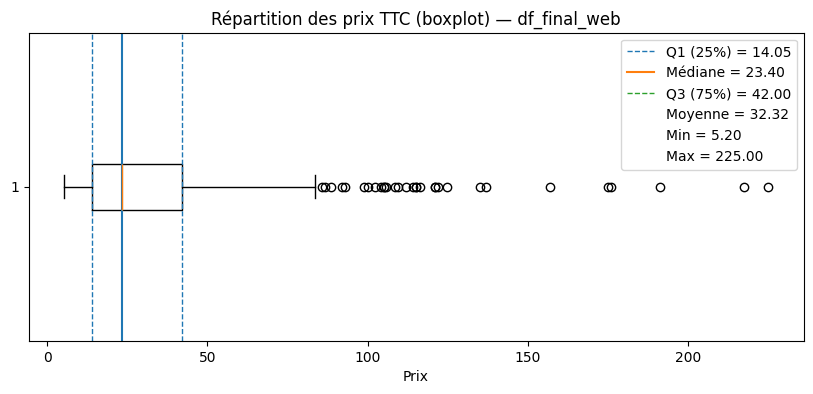

In [92]:
# ===============================================================================
# Boxplot (boîte à moustaches) : PRICE (exprimés TTC)
# Objectif : visualiser la dispersion et repérer rapidement les valeurs extrêmes.
# ==============================================================================

import matplotlib.pyplot as plt

s = df_final_web["price"].dropna()

q1  = s.quantile(0.25)
med = s.quantile(0.50)
q3  = s.quantile(0.75)

mean_ = s.mean()
min_  = s.min()
max_  = s.max()

fig, ax = plt.subplots(figsize=(10, 4))

# Boxplot horizontal
ax.boxplot(s, vert=False, showfliers=True)
ax.set_title("Répartition des prix TTC (boxplot) — df_final_web")
ax.set_xlabel("Prix")

# Traits (Q1 / médiane / Q3)
ax.axvline(q1,  linestyle="--", linewidth=1)
ax.axvline(med, linestyle="-",  linewidth=1.5)
ax.axvline(q3,  linestyle="--", linewidth=1)

# Légende : quartiles + stats de base
ax.plot([], [], linestyle="--", linewidth=1,   label=f"Q1 (25%) = {q1:.2f}")
ax.plot([], [], linestyle="-",  linewidth=1.5, label=f"Médiane = {med:.2f}")
ax.plot([], [], linestyle="--", linewidth=1,   label=f"Q3 (75%) = {q3:.2f}")

# “lignes fantômes” sans style pour ajouter du texte
ax.plot([], [], alpha=0, label=f"Moyenne = {mean_:.2f}")
ax.plot([], [], alpha=0, label=f"Min = {min_:.2f}")
ax.plot([], [], alpha=0, label=f"Max = {max_:.2f}")

ax.legend(loc="upper right", frameon=True)

plt.show()


### Lecture de la boîte à moustaches — variable `price` (périmètre **df_final_web**)

La distribution des prix est **fortement asymétrique à droite** : la majorité des produits se concentre sur une zone de prix “courante” (boîte relativement resserrée), tandis qu’une **traîne de valeurs élevées** s’étire nettement vers la droite.

- **Q1 (25%) = 14,60 €**  
- **Médiane (50%) = 24,40 €** → le “prix typique” est plutôt **bas / modéré**  
- **Q3 (75%) = 42,00 €**  
➡️ Concrètement, **50%** des produits ont un prix compris entre **14,60 € et 42,00 €** (IQR = 27,40 €).

Les moustaches montent jusqu’à la zone des prix élevés, puis on observe des points isolés au-delà :
- En approche IQR (seuil usuel 1,5×IQR), la **borne haute théorique** est **83,10 €** : au-delà, on parle de **prix atypiques** (outliers).
- Les valeurs extrêmes observées vont jusqu’à **225,00 €** (max).  
- À l’inverse, le **minimum** est **5,20 €**.

Enfin, la **moyenne** (**32,36 €**) est nettement au-dessus de la médiane (**24,40 €**) : elle est **tirée vers le haut** par les prix élevés.

**Interprétation métier :** la présence d’outliers peut s’expliquer par
- des produits réellement **premium** (parfaitement plausible),
- ou des **anomalies** (erreur de saisie, unité, doublon, règle promo mal codée, etc.).

➡️ **Conséquence pour la suite :** une lecture à la **moyenne** seule serait peu représentative. On complète donc par une détection statistique des valeurs extrêmes (**Z-score** et surtout **IQR**, plus robuste sur distributions asymétriques) et, si besoin, une visualisation en **échelle logarithmique** pour mieux lire le “cœur” de distribution.



In [93]:
#Autre méthode avec plotly express


In [94]:
import plotly.express as px

fig = px.histogram(
    df_final_web,
    x="price",
    nbins=50,
    title="Distribution des prix TTC (histogramme)"
)
fig.update_layout(xaxis_title="Prix", yaxis_title="Nombre de produits")
fig.show()


In [95]:
# Asymétrie de la distribution des prix (skewness) : >0 = queue à droite, <0 = queue à gauche
skew_price = df_final_web["price"].skew()

# Aplatissement / poids des queues (kurtosis, "excess kurtosis") : >0 = queues lourdes, <0 = queues légères
kurt_price = df_final_web["price"].kurt()  # excess kurtosis (kurtosis - 3)

print(f"Skewness (price) : {skew_price:.3f}")
print(f"Kurtosis (excess) (price) : {kurt_price:.3f}")

Skewness (price) : 2.604
Kurtosis (excess) (price) : 10.365


L’histogramme met en évidence une distribution fortement asymétrique à droite : la majorité des produits se situe sur une plage de prix basse à intermédiaire, tandis qu’une minorité de produits affiche des prix très élevés (queue longue). Cette structure justifie l’utilisation d’indicateurs robustes (médiane, IQR) et motive la recherche d’outliers dans les étapes suivantes (Z-score / IQR), afin de distinguer valeurs extrêmes “métier” vs anomalies.

Les statistiques de forme confirment quantitativement cette lecture :

- **Skewness (price) = 2,604** : asymétrie **positive marquée**, cohérente avec une **queue à droite** (quelques produits tirent la distribution vers les prix élevés).
- **Kurtosis (excess) (price) = 10,365** : kurtose **très élevée** indiquant **beaucoup plus de valeurs extrêmes** que dans une distribution normale (*excess kurtosis ≈ 0*).

➡️ **Implication analytique** : la **moyenne** et l’**écart-type** seront très sensibles à ces extrêmes ; pour caractériser un prix “typique” et poursuivre l’analyse, on privilégiera **médiane / quantiles / IQR**, et l’on pourra utiliser une **échelle logarithmique** pour mieux visualiser le cœur de distribution si nécessaire.


## Etape 4.2 - Exploration par l'utilisation de méthodes statistiques

### Etape 4.2.1 - Identification par le Z-index

### Méthode Z-score (Z-index)

On calcule le **Z-score** de chaque prix : $Z=\dfrac{x-\mu}{\sigma}$.

Un prix est considéré comme **atypique** lorsque **|Z|** dépasse un seuil (souvent **3**).

> ⚠️ **Attention** : cette méthode suppose implicitement une distribution *pas trop éloignée* d’une **normale** ; or nos prix sont **asymétriques**, donc on complètera avec l’approche **IQR** (étape **4.2.2**), plus robuste.



In [96]:
#Calculer la moyenne du prix

#Calculer l'écart-type du prix

#Calculer le Z-score


In [97]:
import numpy as np

# --- Choix du dataset pour l'analyse des prix ---
df_price = df_final_web.copy()

# 1) Moyenne et écart-type
mean_price = df_price["price"].mean()
std_price  = df_price["price"].std(ddof=0)  # ddof=0 = écart-type "population" (cohérent pour un dataset complet)

print(f"Moyenne des prix TTC : {mean_price:.2f}")
print(f"Ecart-type des prix TTC : {std_price:.2f}")

# 2) Calcul du Z-score
df_price["z_score_price"] = (df_price["price"] - mean_price) / std_price

# 3) Seuils usuels (±3 souvent utilisé en détection d'anomalies)
threshold = 3
outliers_z = df_price.loc[df_price["z_score_price"].abs() > threshold,
                          ["product_id", "price", "z_score_price"]].sort_values("z_score_price")

print(f"Nb d'outliers (|Z| > {threshold}) : {len(outliers_z)}")
display(outliers_z.head(20))


Moyenne des prix TTC : 32.32
Ecart-type des prix TTC : 27.59
Nb d'outliers (|Z| > 3) : 13


,product_id,price,z_score_price
699,6202,116.4,3.047320
705,6213,121.0,3.214032
708,6216,121.0,3.214032
647,5917,122.0,3.250273
553,5612,124.8,3.351750
693,6126,135.0,3.721415
410,4904,137.0,3.793898
229,4406,157.0,4.518731
594,5767,175.0,5.171081
226,4402,176.0,5.207322


In [98]:
#Quel est le seuil prix dont le z-score est supérieur à 3?


In [99]:
mu = df_final_web["price"].mean()
sigma = df_final_web["price"].std(ddof=0)  # ddof=0 = écart-type population

seuil_haut = mu + 3 * sigma
seuil_bas  = mu - 3 * sigma

print(f"μ (moyenne) = {mu:.2f}")
print(f"σ (écart-type) = {sigma:.2f}")
print(f"Seuil Z>3 : price > {seuil_haut:.2f}")
print(f"Seuil Z<-3 : price < {seuil_bas:.2f}")

μ (moyenne) = 32.32
σ (écart-type) = 27.59
Seuil Z>3 : price > 115.09
Seuil Z<-3 : price < -50.46


### Conclusion – Méthode Z-score (df_final_web)

Sur le périmètre **df_final_web (713 produits)**, le calcul du Z-score confirme que la distribution des prix comporte **une poignée de valeurs très élevées**.

- Avec le seuil usuel **|Z| > 3**, on identifie **13 produits “atypiques”** sur la variable *price*.
- Le seuil correspondant en valeur absolue est ici :
  - **Seuil haut** : `price > 115.09 €` (puisque μ ≈ 32.32 et σ ≈ 27.59)
  - **Seuil bas** : `price < -50.46 €` → seuil **non pertinent économiquement** pour un prix (sauf données aberrantes), donc il est normal de ne pas détecter d’outliers “bas”.

**Interprétation métier :**
- Ces 13 produits peuvent correspondre à des références **premium** (cas plausible) → outliers *justifiés*.
- Ils peuvent aussi révéler des **anomalies** (erreur de saisie, unité, prix promo mal codé, etc.) → outliers à **auditer**.

⚠️ **Limite** : le Z-score s’appuie sur la **moyenne** et l’**écart-type**, donc il est **sensible à l’asymétrie** et aux **queues longues** (ce qui est le cas ici).  
➡️ On conserve donc ce résultat comme **premier repérage**, puis on **complète** avec une méthode plus robuste (IQR) pour confirmer la détection des valeurs extrêmes.


### Etape 4.2.2 - Identification par l'intervalle interquartile

### Méthode IQR (intervalle interquartile)

L’approche **IQR** repère les valeurs atypiques en s’appuyant sur les **quartiles**, donc sans supposer une distribution “normale” (contrairement au Z-score).

- **Q1** : 25% des prix sont en dessous  
- **Q3** : 75% des prix sont en dessous  
- **IQR = Q3 − Q1** : dispersion “centrale” des prix

On définit ensuite des bornes usuelles :
- **Borne basse** = Q1 − 1.5 × IQR  
- **Borne haute** = Q3 + 1.5 × IQR  

Tout prix en dehors de ces bornes est considéré comme **atypique** (outlier).  
Cette méthode est généralement **plus robuste** quand la distribution est asymétrique (ce qui est notre cas).


In [100]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion


In [101]:
# --- Statistiques descriptives (inclut quartiles) ---
desc = df_price["price"].describe().round(2)
display(desc)

,price
count,713.00
mean,32.32
std,27.61
min,5.20
25%,14.05
50%,23.40
75%,42.00
max,225.00


In [102]:
#Définir un seuil pour les articles "outliers" en prix


In [103]:
# --- Calcul IQR ---
q1 = desc["25%"]
q3 = desc["75%"]
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1 (25%) : {q1:.2f}")
print(f"Q3 (75%) : {q3:.2f}")
print(f"IQR      : {iqr:.2f}")
print(f"Borne basse (Q1 - 1.5*IQR) : {lower:.2f}")
print(f"Borne haute (Q3 + 1.5*IQR) : {upper:.2f}")


Q1 (25%) : 14.05
Q3 (75%) : 42.00
IQR      : 27.95
Borne basse (Q1 - 1.5*IQR) : -27.87
Borne haute (Q3 + 1.5*IQR) : 83.92


In [104]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"


In [105]:
# --- Nombre + proportion d'outliers (prix atypiques) dans le catalogue ---
mask_iqr_outliers = (df_price["price"] < lower) | (df_price["price"] > upper)
nb_outliers = mask_iqr_outliers.sum()
nb_total = len(df_price)
pct_outliers = nb_outliers / nb_total * 100

print(f"Nombre d'articles atypiques (IQR) : {nb_outliers}")
print(f"Proportion d'outliers dans le catalogue : {pct_outliers:.2f}%")
print("")

# Affichage des outliers
print("Affichage des outliers")
print("-"*30)
display(
    df_price.loc[mask_iqr_outliers, ["product_id", "product_type", "price", "purchase_price", "stock_quantity", "stock_status"]]
            .sort_values("price")
            .head(31)
)

Nombre d'articles atypiques (IQR) : 31
Proportion d'outliers dans le catalogue : 4.35%

Affichage des outliers
------------------------------


,product_id,product_type,price,purchase_price,stock_quantity,stock_status
213,4359,Champagne,85.6,51.93,112,instock
473,5026,Champagne,86.8,50.13,101,instock
68,4132,Vin,88.4,44.30,7,instock
542,5565,Vin,92.0,46.11,0,outofstock
646,5916,Whisky,93.0,40.49,1,instock
706,6214,Vin,99.0,49.62,9,instock
66,4115,Vin,100.0,52.70,12,instock
409,4903,Vin,102.3,51.80,12,instock
230,4407,Cognac,104.0,46.71,14,instock
464,5008,Vin,105.0,56.42,12,instock


### Conclusion – Méthode IQR (intervalle interquartile)

Avec la méthode IQR, on obtient :
- **Q1 = 14,05 €**, **Q3 = 42,00 €**, soit **IQR = 27,95 €**
- **Borne haute = 83,92 €** (la borne basse est négative, donc sans enjeu métier ici)

En appliquant la règle des **1,5 × IQR**, on identifie **31 produits** dont le prix est **> 83,92 €**, soit **4,35 %** du catalogue analysé (**31 / 713**).

✅ **Interprétation** : l’IQR confirme l’existence d’un **petit noyau de prix “premium”** (ou atypiques) qui tirent la distribution vers la droite, tout en restant **limité en volume** (~4 %).  
📌 **Point important** : cette méthode est **plus robuste que le Z-score** dans notre cas, car la distribution des prix est **asymétrique** (queue droite longue). On peut donc s’appuyer sur ces 31 produits comme **base prioritaire de contrôle métier** (produits réellement haut de gamme vs erreurs de saisie, unité, doublons, etc.).


In [106]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?


### Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer ?

À ce stade, **on ne peut pas affirmer** que les outliers sont *tous* justifiés ou *tous* anormaux : la méthode IQR/Z-score **signale** des prix atypiques, mais **ne qualifie pas** leur nature.  
En revanche, le fait qu’ils se concentrent sur des catégories “premium” (*Champagne, Whisky, Cognac, Vin*) rend l’hypothèse **métier plausible** : une partie des valeurs élevées est probablement **légitime**.

#### Comment le démontrer (démarche “audit” simple)
1. **Contrôle de cohérence prix vs catégorie**
   - Comparer la distribution des prix **par `product_type`** (médiane, IQR, percentiles).
   - Un outlier “justifié” est souvent un prix élevé **cohérent avec une catégorie haut de gamme**.

2. **Analyse marge / coût d’achat**
   - Calculer **taux de marge** (ex. `(price - purchase_price) / price`).
   - Red flags : marges négatives, marges aberrantes (très proches de 0% ou > 80–90%), incohérences répétées.
   - Si les outliers ont des marges “normales” pour le secteur, ça plaide pour du **premium réel**.

3. **Vérification des métadonnées produit**
   - Examiner `post_title` : présence d’indices “premium” (millésime, grand cru, domaine réputé, rareté).
   - Contrôler la **cohérence de l’unité** (bouteille vs caisse, lot, magnum, etc.) : une unité mal interprétée crée des “outliers” artificiels.

4. **Validation “terrain” (si possible)**
   - Croiser avec une source externe : page produit, tarif fournisseur, ou catalogue interne.
   - Sur un échantillon (top 10 prix), confirmer que le prix affiché correspond bien au produit.

5. **Impact analytique**
   - Recalculer les indicateurs (moyenne, CA) **avec et sans outliers**.
   - Si l’impact est fort, il faut **documenter** la décision : conserver (premium) vs corriger/exclure (anomalie).

✅ **Conclusion opérationnelle** : les outliers sont **potentiellement justifiés** (effet “gamme premium”), mais la preuve passe par des contrôles de cohérence (catégorie, marge, unité, libellé) et, idéalement, une validation sur un petit échantillon.



# Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée

## Etape 5.1 - Analyse des ventes en CA

In [107]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
#Calculer la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web


Objectif : estimer le **CA théorique** généré sur le site e-commerce à partir des données disponibles.

Hypothèse de calcul :
- `total_sales` = **quantité vendue** (nombre d’unités vendues par produit)
- `price` = **prix unitaire TTC** (issu de l’ERP)

On calcule donc un **CA TTC par article** : CA_produit = price * total_sales

Puis on somme l’ensemble des CA par article pour obtenir une estimation du **CA total**.

⚠️ Remarque : les produits sans information Web ont été exclus (dataset `df_final_web`), car `total_sales` y est manquant.


In [108]:
# On travaille sur le périmètre avec données Web disponibles
df_ca = df_final_web.copy()

# CA par article
df_ca["ca_par_article"] = df_ca["price"] * df_ca["total_sales"]

# CA total du site (estimation)
ca_total = df_ca["ca_par_article"].sum()

print("Nombre de produits pris en compte :", len(df_ca))
print("CA TTC total estimé (Σ price * total_sales) :", round(ca_total, 2)," , les prix étant par hypothèse exprimés TTC")

print("-"*40)
print("Visualisation de df_ca pour les colonnes 'price', 'total_sales' et 'ca_par_article")
df_ca[["price", "total_sales", "ca_par_article"]].head()

Nombre de produits pris en compte : 713
CA TTC total estimé (Σ price * total_sales) : 143324.1  , les prix étant par hypothèse exprimés TTC
----------------------------------------
Visualisation de df_ca pour les colonnes 'price', 'total_sales' et 'ca_par_article


,price,total_sales,ca_par_article
0,24.2,6.0,145.2
1,34.3,9.0,308.7
2,20.8,0.0,0.0
3,14.1,12.0,169.2
4,46.0,3.0,138.0


In [109]:
# Top produits contributeurs au CA
top_ca = (
    df_ca[["product_id", "product_type", "post_title", "price", "total_sales", "ca_par_article"]]
    .sort_values("ca_par_article", ascending=False)
    .head(10)
)

print("Top 10 des produits contributeurs au CA")
print("-"*50)
display(top_ca)

Top 10 des produits contributeurs au CA
--------------------------------------------------


,product_id,product_type,post_title,price,total_sales,ca_par_article
207,4352,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,11.0,2475.0
631,5892,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,6.0,1147.8
208,4353,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.5,14.0,1113.0
626,5826,Vin,Agnès Levet Côte Rôtie Améthyste 2017,41.2,20.0,824.0
704,6212,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.0,7.0,805.0
473,5026,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,86.8,9.0,781.2
464,5008,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.0,7.0,735.0
594,5767,Vin,Camille Giroud Clos de Vougeot 2016,175.0,4.0,700.0
693,6126,Champagne,Champagne Gosset Célébris Vintage 2007,135.0,5.0,675.0
472,5025,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,112.0,6.0,672.0


In [110]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premiers articles en CA

#Graphique en barre des 20 premiers articles avec plotly express


In [111]:
################################
# Palmarès des articles en CA  #
################################

import pandas as pd
import plotly.express as px

# 1) Trier par CA décroissant
df_ca_sorted = df_ca.sort_values("ca_par_article", ascending=False)

# 2) Réinitialiser l’index
df_ca_sorted = df_ca_sorted.reset_index(drop=True)

# 3) Afficher les 20 premiers articles en CA
cols_show = ["product_id", "price", "total_sales", "ca_par_article", "product_type", "post_title"]

print("Palmarès des 20 premiers articles en CA TTC")
print("-"*50
      )
display(df_ca_sorted[cols_show].head(20))

# 4) Graphique en barres des 20 premiers articles (Plotly Express)
top20 = df_ca_sorted.head(20).copy()

fig = px.bar(
    top20,
    x="post_title",
    y="ca_par_article",
    color="product_type",
    hover_data=["product_id", "price", "total_sales", "product_type"],
    title="Top 20 articles par CA TTC estimé (price × total_sales)"
)

fig.update_layout(
    xaxis_title="Article (post_title)",
    yaxis_title="CA estimé",
    xaxis_tickangle=-45
)

fig.show()


Palmarès des 20 premiers articles en CA TTC
--------------------------------------------------


,product_id,price,total_sales,ca_par_article,product_type,post_title
0,4352,225.0,11.0,2475.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008
1,5892,191.3,6.0,1147.8,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...
2,4353,79.5,14.0,1113.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé
3,5826,41.2,20.0,824.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017
4,6212,115.0,7.0,805.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...
5,5026,86.8,9.0,781.2,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...
6,5008,105.0,7.0,735.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...
7,5767,175.0,4.0,700.0,Vin,Camille Giroud Clos de Vougeot 2016
8,6126,135.0,5.0,675.0,Champagne,Champagne Gosset Célébris Vintage 2007
9,5025,112.0,6.0,672.0,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...


In [112]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web


In [113]:
# 0) On part d’un dataset CA déjà calculé : df_ca avec la colonne "ca_par_article"
df_8020 = df_ca.copy()

# 1) Créer une colonne "part_ca" = part du CA de chaque ligne
ca_total = df_8020["ca_par_article"].sum()
df_8020["part_ca"] = df_8020["ca_par_article"] / ca_total

# 2) Trier décroissant + créer la somme cumulative
df_8020 = df_8020.sort_values("ca_par_article", ascending=False).reset_index(drop=True)
df_8020["part_ca_cumulee"] = df_8020["part_ca"].cumsum()

# 3) Nombre d’articles nécessaires pour atteindre 80% du CA
seuil = 0.80
n_80 = (df_8020["part_ca_cumulee"] <= seuil).sum() + 1  # +1 pour inclure la ligne qui franchit le seuil
df_top80 = df_8020.head(n_80).copy()

# 4) Proportion de ce groupe dans le catalogue (périmètre analysé)
nb_total = len(df_8020)
prop_catalogue = n_80 / nb_total

print(f"CA TTC total estimé : {ca_total:,.2f}")
print(f"Nombre d'articles pour atteindre 80% du CA TTC : {n_80} / {nb_total}")
print(f"Part du catalogue correspondante : {prop_catalogue:.1%}")
print(f"CA TTC cumulé atteint par ce groupe : {df_top80['part_ca'].sum():.1%}")

# Aperçu des 10 premiers contributeurs
print("-"*50)
print("Affichage des 10 premiers contributeurs")
display(df_8020[["product_id","post_title","price","total_sales","ca_par_article","part_ca","part_ca_cumulee"]].head(10))


CA TTC total estimé : 143,324.10
Nombre d'articles pour atteindre 80% du CA TTC : 434 / 713
Part du catalogue correspondante : 60.9%
CA TTC cumulé atteint par ce groupe : 80.0%
--------------------------------------------------
Affichage des 10 premiers contributeurs


,product_id,post_title,price,total_sales,ca_par_article,part_ca,part_ca_cumulee
0,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,11.0,2475.0,0.017269,0.017269
1,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,6.0,1147.8,0.008008,0.025277
2,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.5,14.0,1113.0,0.007766,0.033043
3,5826,Agnès Levet Côte Rôtie Améthyste 2017,41.2,20.0,824.0,0.005749,0.038792
4,6212,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.0,7.0,805.0,0.005617,0.044408
5,5026,Champagne Agrapart &amp; Fils Minéral Extra Br...,86.8,9.0,781.2,0.005451,0.049859
6,5008,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.0,7.0,735.0,0.005128,0.054987
7,5767,Camille Giroud Clos de Vougeot 2016,175.0,4.0,700.0,0.004884,0.059871
8,6126,Champagne Gosset Célébris Vintage 2007,135.0,5.0,675.0,0.004710,0.064581
9,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,112.0,6.0,672.0,0.004689,0.069270


**Diagramme de Pareto du Chiffre d'affaires**


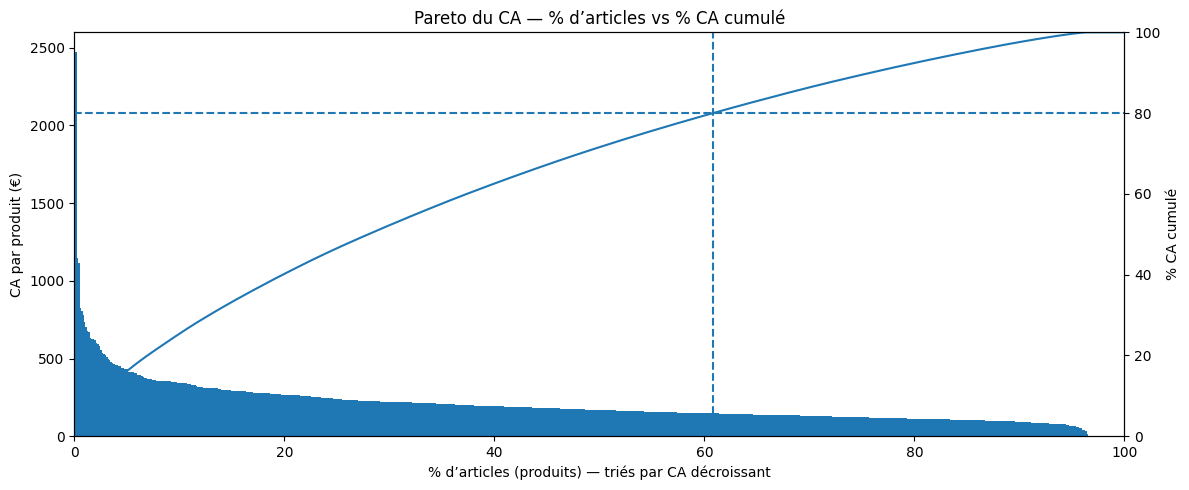

80% du CA atteint avec 434 produits sur 713 (60.9% du catalogue ; x ≈ 60.9%)


In [114]:
# Diagramme de Pareto du Chiffre d'affaires
# ------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

n = len(df_8020)

# Axe X = % d'articles (0 → 100)
x_pct = (np.arange(n) + 1) / n * 100  # +1 pour éviter de commencer à 0 pile

fig, ax1 = plt.subplots(figsize=(12, 5))

# Barres : CA par produit (on garde les barres, mais l'échelle X devient %)
ax1.bar(x_pct, df_8020["ca_par_article"], width=100/n)
ax1.set_xlabel("% d’articles (produits) — triés par CA décroissant")
ax1.set_ylabel("CA par produit (€)")
ax1.set_xlim(0, 100)
ax1.set_xticks([0, 20, 40, 60, 80, 100])

# Courbe : % CA cumulé
ax2 = ax1.twinx()
ax2.plot(x_pct, df_8020["part_ca_cumulee"] * 100)
ax2.set_ylabel("% CA cumulé")
ax2.set_ylim(0, 100)

# Repère 80% (optionnel) + verticale au % d’articles correspondant
seuil = 0.80
idx80 = int((df_8020["part_ca_cumulee"] < seuil).sum())
x80_pct = x_pct[idx80] if idx80 < n else 100

ax2.axhline(80, linestyle="--")
ax2.axvline(x80_pct, linestyle="--")

plt.title("Pareto du CA — % d’articles vs % CA cumulé")
plt.tight_layout()
plt.show()

print(f"80% du CA atteint avec {idx80+1} produits sur {n} "
      f"({(idx80+1)/n:.1%} du catalogue ; x ≈ {x80_pct:.1f}%)")



Le CA n’est pas concentré sur une minorité de produits : il faut ~61% du catalogue pour expliquer 80% du CA. Le profil est donc peu concentré (long tail), ce qui suggère une contribution plus homogène des références. La règle 20/80 n’est pas observée sur ce périmètre et avec cette mesure de CA

## Etape 5.2 - Analyse des ventes en quantité

In [115]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premiers articles en quantité

#Graphique en barre des 20 premiers articles avec plotly express


### Objectif : analyser les ventes en quantité (unités vendues)

Ici, on ne raisonne plus en **chiffre d’affaires**, mais en **volumes** :  
- `total_sales` = **quantité vendue** (nombre d’unités vendues par produit, côté Web)  
- On travaille donc sur le périmètre **où `total_sales` est disponible**, c’est-à-dire notre dataset `df_final_web`.

La démarche est simple :
1. **Trier** les produits par `total_sales` décroissant,
2. **Afficher** les 20 produits les plus vendus,
3. **Visualiser** ce palmarès avec un graphique en barres.

> À noter : un produit peut être **leader en quantité** sans être leader en CA (prix unitaire faible), et inversement.


In [116]:
df_qty = df_final_web.copy()

print("Nb produits analysés (avec données Web) :", len(df_qty))
print("Quantités vendues manquantes :", df_qty["total_sales"].isna().sum())
print("")

# Tri décroissant sur les quantités vendues
df_qty_sorted = df_qty.sort_values("total_sales", ascending=False).reset_index(drop=True)

# Afficher les 20 premiers articles en quantité
cols_show = ["product_id", "post_title", "product_type", "price", "total_sales"]
print("20 premiers articles en quantités vendues")
print("-"*50)
display(df_qty_sorted[cols_show].head(20))

# Graphique en barres des 20 premiers articles (Plotly)
import plotly.express as px

top20_qty = df_qty_sorted.head(20).copy()

fig = px.bar(
    top20_qty,
    x="post_title",
    y="total_sales",
    color="product_type",
    title="Top 20 des articles par quantités vendues (total_sales)",
    labels={"post_title": "Article", "total_sales": "Quantités vendues"}
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()


Nb produits analysés (avec données Web) : 713
Quantités vendues manquantes : 0

20 premiers articles en quantités vendues
--------------------------------------------------


,product_id,post_title,product_type,price,total_sales
0,4867,Château De La Selve IGP Coteaux de l'Ardèche M...,Vin,9.9,36.0
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin,9.9,27.0
2,4275,I Fabbri Chianti Classico Lamole 2017,Vin,14.9,24.0
3,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,Vin,28.5,22.0
4,4726,François Baur Pinot Noir Schlittweg 2017,Vin,12.7,22.0
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Vin,5.2,20.0
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,Vin,41.2,20.0
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pi...,Vin,11.6,18.0
8,5778,Maurel Pays d'Oc Merlot 2018,Vin,5.8,17.0
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,Vin,29.0,17.0


In [117]:
#####################################
# Calculer le 20 / 80 en Quantités #
#####################################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web


In [118]:
df_qty = df_final_web.copy()

# 1) Trier par quantités vendues décroissantes
df_qty = df_qty.sort_values("total_sales", ascending=False).reset_index(drop=True)

# 2) Part en quantité de chaque produit
total_qty = df_qty["total_sales"].sum()
df_qty["part_qty"] = df_qty["total_sales"] / total_qty

# 3) Cumul des parts
df_qty["part_qty_cumulee"] = df_qty["part_qty"].cumsum()

# 4) Nombre d’articles nécessaires pour atteindre 80% des ventes en quantité
nb_80 = (df_qty["part_qty_cumulee"] <= 0.80).sum() + 1   # +1 pour inclure la ligne qui franchit le seuil
prop_catalogue = nb_80 / len(df_qty)

print(f"Quantités totales vendues : {total_qty:,.0f}")
print(f"Nombre d'articles pour atteindre 80% des ventes en quantité : {nb_80}")
print(f"Part du catalogue correspondante : {prop_catalogue:.1%}, soit {n_80} / {nb_total}")
print(f"Quantités cumulées atteintes par ce groupe : {df_qty.loc[nb_80-1, 'part_qty_cumulee']:.1%}")

print("-"*60)
print("")
print("Affichage des 10 premiers contributeurs (quantités vendues) :")
print("-"*60)
display(
    df_qty.loc[:9, ["product_id", "post_title", "price", "total_sales", "part_qty", "part_qty_cumulee"]]
)

Quantités totales vendues : 5,743
Nombre d'articles pour atteindre 80% des ventes en quantité : 433
Part du catalogue correspondante : 60.7%, soit 434 / 713
Quantités cumulées atteintes par ce groupe : 80.1%
------------------------------------------------------------

Affichage des 10 premiers contributeurs (quantités vendues) :
------------------------------------------------------------


,product_id,post_title,price,total_sales,part_qty,part_qty_cumulee
0,4867,Château De La Selve IGP Coteaux de l'Ardèche M...,9.9,36.0,0.006269,0.006269
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,9.9,27.0,0.004701,0.010970
2,4275,I Fabbri Chianti Classico Lamole 2017,14.9,24.0,0.004179,0.015149
3,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,28.5,22.0,0.003831,0.018980
4,4726,François Baur Pinot Noir Schlittweg 2017,12.7,22.0,0.003831,0.022810
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,5.2,20.0,0.003483,0.026293
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,41.2,20.0,0.003483,0.029775
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pi...,11.6,18.0,0.003134,0.032910
8,5778,Maurel Pays d'Oc Merlot 2018,5.8,17.0,0.002960,0.035870
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,29.0,17.0,0.002960,0.038830


**Diagramme de Pareto des quantités**

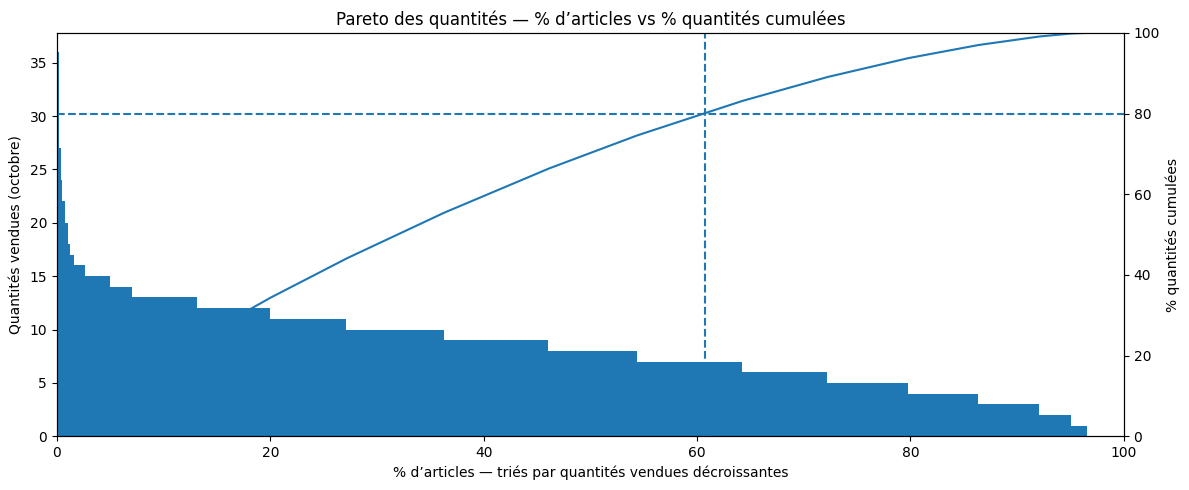

80% des quantités atteint avec 433 produits sur 713 (60.7% du catalogue ; x ≈ 60.7%)


In [119]:
# Diagramme de Pareto des quantités vendues
# ----------------------------------------
import numpy as np
import matplotlib.pyplot as plt

n = len(df_qty)

# Axe X = % d'articles (produits) triés par quantités décroissantes
x_pct = (np.arange(n) + 1) / n * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

# Barres : quantités vendues par produit
ax1.bar(x_pct, df_qty["total_sales"], width=100/n)
ax1.set_xlabel("% d’articles — triés par quantités vendues décroissantes")
ax1.set_ylabel("Quantités vendues (octobre)")
ax1.set_xlim(0, 100)
ax1.set_xticks([0, 20, 40, 60, 80, 100])

# Courbe : % quantités cumulées
ax2 = ax1.twinx()
ax2.plot(x_pct, df_qty["part_qty_cumulee"] * 100)
ax2.set_ylabel("% quantités cumulées")
ax2.set_ylim(0, 100)

# Repères 80%
seuil = 0.80
idx80 = int((df_qty["part_qty_cumulee"] < seuil).sum())
x80_pct = x_pct[idx80] if idx80 < n else 100
ax2.axhline(80, linestyle="--")
ax2.axvline(x80_pct, linestyle="--")

plt.title("Pareto des quantités — % d’articles vs % quantités cumulées")
plt.tight_layout()
plt.show()

print(f"80% des quantités atteint avec {idx80+1} produits sur {n} "
      f"({(idx80+1)/n:.1%} du catalogue ; x ≈ {x80_pct:.1f}%)")


### Mise en perspective CA vs Quantités : un “Pareto” très atténué

On constate que la logique **20/80** n’est **pas** vérifiée, ni en **chiffre d’affaires**, ni en **quantités vendues**.  
Dans les deux cas, il faut mobiliser **environ 60% du catalogue** (60.9 versus 60.7) pour atteindre **80%** du total.

➡️ **Interprétation :** on n’est pas sur un modèle “quelques best-sellers qui font le marché”, mais plutôt sur une **distribution diffuse** :  
- beaucoup de références contribuent,  
- aucune minorité de produits ne “porte” à elle seule l’essentiel de l’activité,  
- l’activité ressemble à une **longue traîne** (large assortiment, ventes réparties).

💡 **Conséquence opérationnelle :** l’optimisation ne peut pas se limiter à choyer 20% des produits : il faut piloter **un socle large** (assortiment, disponibilité, pricing) et compléter l’analyse par des angles plus discriminants (marge, rotation, stock, familles produit, etc.).


## Etape 5.3 - Analyse des stocks

### 🔎 Préambule méthodologique — marges & stocks (ce qu’on peut faire… et ce qu’on ne peut pas)

Nous travaillons sur une extraction **au 31/10** et des ventes **du 01/10 au 31/10**.  
Variables disponibles : `price`, `purchase_price`, `stock_quantity` (stock au 31/10), `total_sales` (quantités vendues en octobre).

---

## 1) Marges : ici, on ne peut raisonner proprement qu’en **marge unitaire**
En “vraie” comptabilité / contrôle de gestion, une **marge globale période** se raisonne en intégrant la variation de stocks :

- **Coût d’achat des marchandises vendues (CAMV / COGS)**  
  - CAMV = Stock_initial + Achats - Stock_final
- **Marge brute globale (période)**  
  - Marge_brute_globale = CA - CAMV

👉 Problème : ici, nous n’avons **ni stock initial au 01/10**, ni les **achats/entrées** du mois.  
Donc on ne peut **pas** reconstituer un **CAMV** fiable, et donc **pas** calculer une *marge globale “comptable”* au sens strict (tous produits confondus).

✅ Ce que l’on peut calculer sans hypothèse abusive, c’est la **marge au niveau produit** (unitaire), car elle dépend uniquement de prix unitaires :

- **Marge unitaire**  
  - Marge_unitaire = price - purchase_price
- **Taux de marge unitaire** (sur coût d’achat)  
  - Taux_de_marge_unitaire = (price - purchase_price) / purchase_price   (si purchase_price > 0)

> Remarque : on peut aussi produire une **“marge sur ventes d’octobre” par produit** :
- Marge_octobre_produit = (price - purchase_price) * total_sales
> Mais cela reste une approche “ligne à ligne” basée sur les ventes, **pas** une marge globale intégrant les variations de stock et achats.

---

## 2) Rotation des stocks : formule réelle… et pourquoi on ne peut pas la calculer ici
La rotation sur une période se calcule classiquement à partir d’un **stock moyen** :

- **Stock moyen (période)**  
 - Stock_moyen = (Stock_initial + Stock_final) / 2
- **Rotation (en nombre de rotations sur la période)**  
  - Rotation_quantités = Quantités_vendues / Stock_moyen_qté
  - Rotation_valeur = CAMV / Stock_moyen

👉 Ici, on ne connaît que **`stock_quantity` au 31/10** (= stock final).  
On ne connaît **pas** le stock au 01/10 (= stock initial), et **on ne peut pas supposer qu’il est nul** : en e-commerce, un stock initial non nul est la norme, pas l’exception.

➡️ Conclusion : **rotation académique impossible** (stock initial manquant → stock moyen inconnu).

---

## 3) Approximation acceptable : parler de **couverture** (stock coverage) au 31/10
À défaut de rotation, on peut fournir un indicateur opérationnel cohérent avec les données : la **couverture de stock** au 31/10, basée sur les ventes du mois.

- **Couverture (en mois)**  
  - Couverture_en_mois = stock_quantity / total_sales    (si total_sales > 0)
- **Couverture (en jours)**  
  - Couverture_en_jours = 30 * stock_quantity / total_sales   (sur octobre)

> Lecture : “si le rythme de ventes d’octobre se maintient, combien de mois/jours de stock reste-t-il au 31/10 ?”
> C’est une **projection**, pas une rotation réelle.

---

✅ **En synthèse**
- Marges : **marge unitaire / taux de marge unitaire** (et éventuellement marge “sur ventes d’octobre” par produit), mais **pas** de marge globale comptable faute de stock initial/achats.
- Stocks : **rotation impossible** (stock initial manquant, hypothèse stock initial = 0 non défendable) ; on calcule plutôt une **couverture** au 31/10.


In [120]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy

#Création de la colonne Rotation de stock

#Remplacement des "inf" (divisions par 0) par 0

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

In [121]:
import numpy as np
import plotly.express as px

# On part du périmètre avec infos Web (ventes) : df_final_web
df_stock = df_final_web.copy()

# 1) Couverture / "mois de stock" (approximation OC)
# Hypothèse OC : total_sales = ventes sur 1 mois (octobre)
# => mois_de_stock = stock_quantity / total_sales
df_stock["mois_stock"] = (df_stock["stock_quantity"] / df_stock["total_sales"]).round(2)

# 2) Remplacement des inf (divisions par 0) par 0 (demande OC)
df_stock["mois_stock"] = (
    df_stock["mois_stock"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

# 3) Tri décroissant (les produits avec le plus de "mois de stock")
df_stock_sorted = df_stock.sort_values("mois_stock", ascending=False).reset_index(drop=True)

# 4) Affichage du top 20 (produits avec le plus de mois de stock)
cols_show = ["product_id", "post_title", "stock_quantity", "total_sales", "mois_stock", "stock_status", "price"]
print("Top 20 des produits avec le plus de mois de stocks")
print("-"*50)
display(df_stock_sorted[cols_show].head(20))
print("")

# 5) Graphique en barres du top 20
fig = px.bar(
    df_stock_sorted.head(20),
    x="post_title",
    y="mois_stock",
    color="product_type",
    title="Top 20 - Produits avec le plus de mois de stock (approximation OC)",
)
fig.update_layout(xaxis_title="Produit", yaxis_title="Mois de stock (stock_quantity / total_sales)")
fig.show()


Top 20 des produits avec le plus de mois de stocks
--------------------------------------------------


,product_id,post_title,stock_quantity,total_sales,mois_stock,stock_status,price
0,4142,Champagne Gosset Grand Millésime 2006,125,4.0,31.25,instock,53.0
1,6126,Champagne Gosset Célébris Vintage 2007,138,5.0,27.60,instock,135.0
2,4356,Champagne Egly-Ouriet Premier Cru Les Vignes d...,81,3.0,27.00,instock,51.6
3,4348,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5.0,25.00,instock,59.0
4,4148,Champagne Mailly Grand Cru Brut Rosé,71,3.0,23.67,instock,37.5
5,4357,Champagne Larmandier-Bernier Latitude,115,5.0,23.00,instock,39.0
6,4144,Champagne Gosset Grand Rosé,91,4.0,22.75,instock,49.0
7,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,136,6.0,22.67,instock,112.0
8,4350,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7.0,20.71,instock,79.5
9,4150,Champagne Mailly Grand Cru Intemporelle 2010,123,6.0,20.50,instock,59.0


### Résultats – Top 20 des produits avec le plus de “mois de stock” (approximation OC)

Sur la période étudiée (ventes du **1er au 31 octobre**, extraction au **31/10**), on calcule une **couverture de stock** exprimée en “mois” selon l’approximation :

- **mois_stock ≈ stock_quantity / total_sales**

**Lecture métier :**
- Un **mois_stock élevé** signifie que le **stock disponible au 31/10** est très important au regard des **ventes réalisées en octobre** → signal de **surstock potentiel**, **rotation lente** et **immobilisation de trésorerie**.
- Le Top 20 regroupe principalement des produits avec **stock_quantity élevé** et/ou **total_sales faible**, ce qui mécaniquement fait monter la couverture (jusqu’à ~30 mois dans nos résultats).

⚠️ **Attention méthodologique :**
- Faute de **stock initial au 01/10**, on ne calcule pas une **rotation de stock au sens “comptable”** ; on interprète plutôt un indicateur **à date** : *“combien de mois de ventes d’octobre le stock actuel représente-t-il ?”*
- Les cas où **total_sales = 0** provoquent une division par zéro (valeur `inf`). On remplace `inf` par **0** pour ne pas bloquer les traitements, mais ces produits doivent idéalement être analysés à part (stock > 0 et aucune vente = signal fort).


In [122]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros

#Calculer la somme de la colonne "Valorisation_stock_euros"

### Valorisation des stocks en euros (au 31/10)

Objectif : estimer la **valeur du stock immobilisé** à la date d’extraction (31/10), à partir des informations disponibles.

**Principe :**
- On valorise chaque ligne de stock en multipliant la **quantité en stock** par un **prix unitaire de référence**.
- Dans une logique “coût” (la plus cohérente pour un stock), on retient en priorité le **prix d’achat HT** (*purchase_price*).  
  À défaut, on peut aussi calculer une valorisation “prix de vente” (price) mais ce n’est pas une valorisation comptable.

**Formule retenue (valorisation au coût) :**
- `valorisation_stock_euros = stock_quantity × purchase_price`

Ensuite, on calcule la **valeur totale du stock** en faisant :
- `stock_total_euros = somme(valorisation_stock_euros)` sur l’ensemble des produits.


In [123]:
# ================================
# Valorisation des stocks en euros
# ================================

df_stock = df_final_web.copy()

# Sécurisation types
df_stock["stock_quantity"] = pd.to_numeric(df_stock["stock_quantity"], errors="coerce")
df_stock["purchase_price"] = pd.to_numeric(df_stock["purchase_price"], errors="coerce")

# 1) Valorisation par produit (au coût)
df_stock["valorisation_stock_euros"] = df_stock["stock_quantity"] * df_stock["purchase_price"]

# 2) Total stock (au coût)
stock_total_euros = df_stock["valorisation_stock_euros"].sum(skipna=True)

print("Valeur totale du stock (au coût d'achat HT) :", round(stock_total_euros, 2))
print("")

# 3) Aperçu (5 premières lignes) sur les colonnes utiles
print("Aperçu (5 premières lignes) sur les colonnes utiles")
print(("-")*50)
display(
    df_stock[["product_id", "post_title", "stock_quantity", "purchase_price", "valorisation_stock_euros"]]
    .sort_values("valorisation_stock_euros", ascending=False)
    .head(5)
)

# --- Variante optionnelle : valorisation "prix de vente TTC" (non comptable, mais parfois demandé en lecture business)
# df_stock["price"] = pd.to_numeric(df_stock["price"], errors="coerce")
# df_stock["valorisation_stock_pv"] = df_stock["stock_quantity"] * df_stock["price"]
# stock_total_pv = df_stock["valorisation_stock_pv"].sum(skipna=True)
# print("Valeur totale du stock (prix de vente) :", round(stock_total_pv, 2))


Valeur totale du stock (au coût d'achat HT) : 277328.07

Aperçu (5 premières lignes) sur les colonnes utiles
--------------------------------------------------


,product_id,post_title,stock_quantity,purchase_price,valorisation_stock_euros
631,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,98,116.06,11373.88
693,6126,Champagne Gosset Célébris Vintage 2007,138,80.33,11085.54
472,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,136,68.60,9329.60
209,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,97,77.48,7515.56
204,4337,Champagne Mailly Grand Cru Les Echansons 2007,145,48.90,7090.50


In [124]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity

In [125]:
# Valorisation du nombre de produits en stock
# --------------------------------------------

df_stock = df_final_web.copy()

# Sécurisation type
df_stock["stock_quantity"] = pd.to_numeric(df_stock["stock_quantity"], errors="coerce")

# Total unités en stock (toutes références confondues)
total_unites_stock = df_stock["stock_quantity"].sum(skipna=True)

print("Nombre total d'unités en stock (Σ stock_quantity) :", int(total_unites_stock))
print("")

# Nb de références avec stock > 0
nb_refs_stock_pos = (df_stock["stock_quantity"] > 0).sum()

print("Nombre de références avec stock > 0 :", int(nb_refs_stock_pos))
print("")

# Nb de références avec stock = 0
nb_refs_stock_zero = (df_stock["stock_quantity"] == 0).sum()

print("Nombre de références avec stock = 0 :", int(nb_refs_stock_zero))
print("")

# Nb de références total pour vérification (attendu 713)
nb_refs_stock_tot = nb_refs_stock_pos + nb_refs_stock_zero

print("Nombre de références total :", int(nb_refs_stock_tot))
print("")

# Aperçu (top 10 stocks)
print("Aperçu (top 10 stocks)")
display(
    df_stock[["product_id", "post_title", "stock_quantity", "stock_status", "total_sales"]]
    .sort_values("stock_quantity", ascending=False)
    .head(10)
)


Nombre total d'unités en stock (Σ stock_quantity) : 16740

Nombre de références avec stock > 0 : 669

Nombre de références avec stock = 0 : 44

Nombre de références total : 713

Aperçu (top 10 stocks)


,product_id,post_title,stock_quantity,stock_status,total_sales
204,4337,Champagne Mailly Grand Cru Les Echansons 2007,145,instock,0.0
206,4350,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,instock,7.0
202,4334,Champagne Gosset Grand Blanc de Blancs,142,instock,7.0
693,6126,Champagne Gosset Célébris Vintage 2007,138,instock,5.0
472,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,136,instock,6.0
208,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,127,instock,14.0
591,5761,Huiles d'Olive Extra Vierge Planeta 3x 10cl,125,instock,10.0
205,4348,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,instock,5.0
73,4142,Champagne Gosset Grand Millésime 2006,125,instock,4.0
72,4141,Champagne Gosset Grande Réserve,123,instock,8.0


### Lecture croisée Stock vs Ventes (stock_quantity vs total_sales)

Sur le périmètre `df_final_web` (713 références), **669 produits** ont un stock strictement positif (≈ 93,8 %).  
Le **Top 10 des stocks** met toutefois en évidence plusieurs références avec **stock très élevé** (123 à 145 unités) pour des **ventes faibles sur la période** (souvent entre 0 et 14 unités, et même **0** pour une référence).

➡️ **Interprétation :**
- Ces produits présentent une **couverture très élevée** (stock important au regard des ventes du mois), ce qui suggère un **risque de surstock** / immobilisation de trésorerie.
- À l’inverse, quelques références cumulent **stock élevé** et **ventes non nulles** : elles peuvent être des “best-sellers” encore correctement approvisionnés, mais la couverture reste à surveiller.

➡️ **Point méthodo (important) :**
`total_sales` correspond aux ventes **du 01/10 au 31/10** (période d’un mois). On parle donc ici d’une **couverture “mois”** :
- plus la couverture est élevée, plus le stock semble disproportionné par rapport au rythme de vente observé.


## Etape 5.4 - Analyse du taux de marge

In [126]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT

#Création de la colonne Taux de marge

#Afficher le prix minimum de la colonne "taux_marge"

#Afficher le prix maximum de la colonne "taux_marge"


In [127]:
############################
# Analyse du taux de marge #
############################

import numpy as np

df_margin = df_final_web.copy()

# --- Paramètre TVA (taux de droit commun retenu) ---
TVA = 0.20

# 1) Prix HT (hypothèse : price est TTC)
df_margin["prix_ht"] = df_margin["price"] / (1 + TVA)

# 2) Taux de marge unitaire en % (ex: 25.23)
df_margin["taux_marge_pct"] = np.where(
    df_margin["purchase_price"] > 0,
    ((df_margin["prix_ht"] - df_margin["purchase_price"]) / df_margin["purchase_price"]) * 100,
    np.nan
)

# 3) Min / Max (déjà en %)
min_tm = df_margin["taux_marge_pct"].min(skipna=True)
max_tm = df_margin["taux_marge_pct"].max(skipna=True)

print(f"Taux de marge min : {min_tm:.2f} %")
print(f"Taux de marge max : {max_tm:.2f} %\n")

cols = ["product_id", "post_title", "price", "prix_ht", "purchase_price", "taux_marge_pct"]

print("Top 10 taux de marge minimums")
print("-"*50)
display(
    df_margin.loc[df_margin["taux_marge_pct"].notna(), cols]
    .sort_values("taux_marge_pct")
    .head(10)
    .style.format({
        "price": "{:.2f}",
        "prix_ht": "{:.2f}",
        "purchase_price": "{:.2f}",
        "taux_marge_pct": "{:.2f} %"
    })
)

print("\nTop 10 taux de marge maximums")
print("-"*50)
display(
    df_margin.loc[df_margin["taux_marge_pct"].notna(), cols]
    .sort_values("taux_marge_pct", ascending=False)
    .head(10)
    .style.format({
        "price": "{:.2f}",
        "prix_ht": "{:.2f}",
        "purchase_price": "{:.2f}",
        "taux_marge_pct": "{:.2f} %"
    })
)

Taux de marge min : -86.39 %
Taux de marge max : 91.41 %

Top 10 taux de marge minimums
--------------------------------------------------


,product_id,post_title,price,prix_ht,purchase_price,taux_marge_pct
209,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,10.54,77.48,-86.39 %
590,5760,Huile d'Olive Extra Vierge Planeta 50cl,13.10,10.92,8.43,29.50 %
72,4141,Champagne Gosset Grande Réserve,39.00,32.50,24.86,30.73 %
591,5761,Huiles d'Olive Extra Vierge Planeta 3x 10cl,19.50,16.25,12.07,34.63 %
474,5027,Champagne Agrapart & Fils Terroirs Brut Blanc de Blancs Grand Cru,62.10,51.75,38.04,36.04 %
589,5756,Huile d'Olive Extra Vierge Planeta Selezione Chef 3L,42.20,35.17,25.85,36.04 %
472,5025,Champagne Agrapart & Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,112.00,93.33,68.60,36.05 %
207,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,187.50,137.81,36.06 %
212,4358,Champagne Larmandier-Bernier Grand Cru Vieilles Vignes du Levant 2008,77.00,64.17,47.16,36.06 %
202,4334,Champagne Gosset Grand Blanc de Blancs,49.00,40.83,30.01,36.07 %



Top 10 taux de marge maximums
--------------------------------------------------


,product_id,post_title,price,prix_ht,purchase_price,taux_marge_pct
225,4401,Cognac Frapin VSOP,62.50,52.08,27.21,91.41 %
646,5916,Wemyss Malts Single Cask Scotch Whisky Chocolate Moka Cake 2005 Strathclyde,93.00,77.50,40.49,91.41 %
229,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,157.00,130.83,69.08,89.39 %
643,5912,Kingsbarns Distillery Lowland Single Malt Whisky,57.00,47.50,25.08,89.39 %
647,5917,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,122.00,101.67,54.24,87.44 %
226,4402,Cognac Frapin VIP XO,176.00,146.67,78.25,87.43 %
215,4391,Wemyss Malts Blended Malt Scotch Whisky Peat Chimney,49.50,41.25,22.01,87.41 %
216,4392,Wemyss Malts Blended Malt Scotch Whisky Spice King,49.50,41.25,22.01,87.41 %
230,4407,Cognac Frapin Cigar Blend,104.00,86.67,46.71,85.54 %
652,5932,Cognac Normandin Mercier VFC,59.90,49.92,27.18,83.65 %


### Analyse du taux de marge (unitaire)

On calcule ici un **taux de marge unitaire** à partir des informations disponibles (prix de vente et prix d’achat).  
Les résultats montrent une **forte dispersion** des marges :

- **Taux de marge minimum : -86,39%**  
  → marge **négative** : le prix de vente (HT) est **inférieur** au prix d’achat.  
  Cela peut traduire :
  - une **erreur de donnée** (prix TTC/HT mal alignés, mauvais prix d’achat, produit mal mappé),
  - une **vente à perte / promo agressive** (possible en e-commerce selon contexte),
  - ou un **coût d’achat exceptionnel** (lot, millésime, unité, conditionnement…).

- **Taux de marge maximum : 91,41%**  
  → marge très élevée : typique de produits à **forte valeur perçue** (spiritueux premium, édition spéciale, etc.)… ou d’un **prix d’achat sous-estimé** / incomplet.

📌 **À retenir :** ces extrêmes sont de bons candidats pour une **revue qualité** (vérifier unités, TVA, cohérence HT/TTC, mapping produit, règles de pricing).  
Autrement dit : certains produits semblent très rentables… et d’autres ressemblent à une opération “charité fiscale” — ce qui mérite un petit audit.


In [128]:
#Affichage de la ligne avec un taux de marge inférieur à 0


In [129]:
# Affichage des produits avec un taux de marge < 0% (marge unitaire négative)
print("Affichage des lignes avec un taux de marge inférieur à 0%")
print("-"*60)

cols = ["product_id", "post_title", "price", "prix_ht", "purchase_price", "taux_marge_pct"]

display(
    df_margin.loc[df_margin["taux_marge_pct"] < 0, cols]
    .sort_values("taux_marge_pct")
    .head(20)  # ajuste si besoin
    .style.format({
        "price": "{:.2f}",
        "prix_ht": "{:.2f}",
        "purchase_price": "{:.2f}",
        "taux_marge_pct": "{:.2f} %"
    })
)

Affichage des lignes avec un taux de marge inférieur à 0%
------------------------------------------------------------


,product_id,post_title,price,prix_ht,purchase_price,taux_marge_pct
209,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,10.54,77.48,-86.39 %


In [130]:
#Création d'un dataframe avec les taux positifs

#Afficher le prix minimum de la colonne "taux_marge"

#Afficher le prix maximum de la colonne "taux_marge"


In [131]:
# Création d'un dataframe avec les taux positifs
df_margin_pos = df_margin.loc[df_margin["taux_marge_pct"].notna() & (df_margin["taux_marge_pct"] > 0)].copy()

# Afficher le taux de marge minimum / maximum (sur les taux positifs)
min_tm_pos = df_margin_pos["taux_marge_pct"].min()
max_tm_pos = df_margin_pos["taux_marge_pct"].max()

print(f"Taux de marge positif min : {min_tm_pos:.2f} %")
print(f"Taux de marge positif max : {max_tm_pos:.2f} %")

# (optionnel) aperçu des extrêmes
cols = ["product_id", "post_title", "price", "prix_ht", "purchase_price", "taux_marge_pct"]

print("\nTop 10 taux de marge positifs minimums")
display(
    df_margin_pos[cols]
    .sort_values("taux_marge_pct")
    .head(10)
    .style.format({
        "price": "{:.2f}",
        "prix_ht": "{:.2f}",
        "purchase_price": "{:.2f}",
        "taux_marge_pct": "{:.2f} %"
    })
)

print("\nTop 10 taux de marge positifs maximums")
display(
    df_margin_pos[cols]
    .sort_values("taux_marge_pct", ascending=False)
    .head(10)
    .style.format({
        "price": "{:.2f}",
        "prix_ht": "{:.2f}",
        "purchase_price": "{:.2f}",
        "taux_marge_pct": "{:.2f} %"
    })
)


Taux de marge positif min : 29.50 %
Taux de marge positif max : 91.41 %

Top 10 taux de marge positifs minimums


,product_id,post_title,price,prix_ht,purchase_price,taux_marge_pct
590,5760,Huile d'Olive Extra Vierge Planeta 50cl,13.10,10.92,8.43,29.50 %
72,4141,Champagne Gosset Grande Réserve,39.00,32.50,24.86,30.73 %
591,5761,Huiles d'Olive Extra Vierge Planeta 3x 10cl,19.50,16.25,12.07,34.63 %
474,5027,Champagne Agrapart & Fils Terroirs Brut Blanc de Blancs Grand Cru,62.10,51.75,38.04,36.04 %
589,5756,Huile d'Olive Extra Vierge Planeta Selezione Chef 3L,42.20,35.17,25.85,36.04 %
472,5025,Champagne Agrapart & Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,112.00,93.33,68.60,36.05 %
207,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,187.50,137.81,36.06 %
212,4358,Champagne Larmandier-Bernier Grand Cru Vieilles Vignes du Levant 2008,77.00,64.17,47.16,36.06 %
202,4334,Champagne Gosset Grand Blanc de Blancs,49.00,40.83,30.01,36.07 %
475,5047,Champagne Petit Lebrun & Fils Blanc de Blancs Grand Cru,22.50,18.75,13.78,36.07 %



Top 10 taux de marge positifs maximums


,product_id,post_title,price,prix_ht,purchase_price,taux_marge_pct
225,4401,Cognac Frapin VSOP,62.50,52.08,27.21,91.41 %
646,5916,Wemyss Malts Single Cask Scotch Whisky Chocolate Moka Cake 2005 Strathclyde,93.00,77.50,40.49,91.41 %
229,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,157.00,130.83,69.08,89.39 %
643,5912,Kingsbarns Distillery Lowland Single Malt Whisky,57.00,47.50,25.08,89.39 %
647,5917,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,122.00,101.67,54.24,87.44 %
226,4402,Cognac Frapin VIP XO,176.00,146.67,78.25,87.43 %
216,4392,Wemyss Malts Blended Malt Scotch Whisky Spice King,49.50,41.25,22.01,87.41 %
215,4391,Wemyss Malts Blended Malt Scotch Whisky Peat Chimney,49.50,41.25,22.01,87.41 %
230,4407,Cognac Frapin Cigar Blend,104.00,86.67,46.71,85.54 %
652,5932,Cognac Normandin Mercier VFC,59.90,49.92,27.18,83.65 %


In [132]:
#Création d'un dataframe avec le taux de marge moyen par type de produit

#Affichage dans un graphique du taux de marge par type de produit


In [133]:
# Taux de marge moyen par type de produit
# -----------------------------------------

import plotly.express as px

# 1) Agrégation : taux de marge moyen par type
df_tm_type = (
    df_margin.loc[df_margin["taux_marge_pct"].notna()]
    .groupby("product_type", as_index=False)
    .agg(
        taux_marge_moyen_pct=("taux_marge_pct", "mean"),
        nb_produits=("product_id", "count")
    )
    .sort_values("taux_marge_moyen_pct", ascending=False)
)

# 2) Format d'affichage % avec 2 décimales
df_tm_type["taux_marge_moyen_pct"] = df_tm_type["taux_marge_moyen_pct"].round(2)
df_tm_type["taux_marge_moyen_fmt"] = df_tm_type["taux_marge_moyen_pct"].map(lambda x: f"{x:.2f}")

print("Aperçu (taux de marge moyen par type) :")
display(df_tm_type[["product_type", "taux_marge_moyen_fmt", "nb_produits"]])

# 3) Graphique : 1 couleur par catégorie
fig = px.bar(
    df_tm_type,
    x="product_type",
    y="taux_marge_moyen_pct",
    color="product_type",  # => couleurs distinctes par type
    text="taux_marge_moyen_fmt",
    hover_data={"nb_produits": True, "taux_marge_moyen_fmt": True, "taux_marge_moyen_pct": False},
    title="Taux de marge moyen par type de produit",
    labels={
        "product_type": "Type de produit",
        "taux_marge_moyen_pct": "Taux de marge moyen en %",
        "nb_produits": "Nb produits"
    }
)

# Axe Y au format "xx.xx"
fig.update_yaxes(tickformat=".2f")
fig.update_traces(textposition="outside", cliponaxis=False)

fig.show()


Aperçu (taux de marge moyen par type) :


,product_type,taux_marge_moyen_fmt,nb_produits
1,Cognac,82.32,8
6,Whisky,81.74,14
2,Gin,74.83,2
5,Vin,61.49,657
4,Non renseigné,56.64,1
0,Champagne,35.44,28
3,Huile d'olive,33.39,3


## Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price

### Corrélations : Pearson vs Spearman (pour `price`, `total_sales`, `stock_quantity`)

Avant de produire les heatmaps, on compare deux mesures de corrélation :

- **Pearson (r)** : mesure l’intensité d’une **relation linéaire** entre deux variables quantitatives.  
  Formule :  
  r = Cov(X, Y) / (σX · σY)  
  ➜ Pertinent si la relation est (à peu près) linéaire et si la distribution n’est pas trop “tordue” par l’asymétrie / les outliers.

- **Spearman (ρ)** : mesure l’intensité d’une **relation monotone** (croissante ou décroissante), en travaillant sur les **rangs** plutôt que sur les valeurs brutes.  
  Formule “théorique” :  
  ρ = 1 − [6 · Σ(dᵢ²)] / [n · (n² − 1)]  
  avec :
  - n = nombre d’observations appariées (lignes où X et Y sont présents),
  - dᵢ = rang(Xᵢ) − rang(Yᵢ).  
  ➜ Plus robuste aux distributions **asymétriques** et aux **valeurs extrêmes** (cas typique de variables comme les ventes).

Dans notre contexte (prix très asymétriques, outliers visibles), on s’attend à ce que **Spearman** capte plus nettement les tendances “globales” que Pearson, car il se focalise sur l’ordre des valeurs plutôt que sur leurs écarts exacts.


In [134]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

Matrice de corrélation Pearson
--------------------------------------------------


,price,total_sales,stock_quantity
price,1.00,-0.52,-0.11
total_sales,-0.52,1.00,0.44
stock_quantity,-0.11,0.44,1.00



Heatmap _ Pearson
--------------------------------------------------


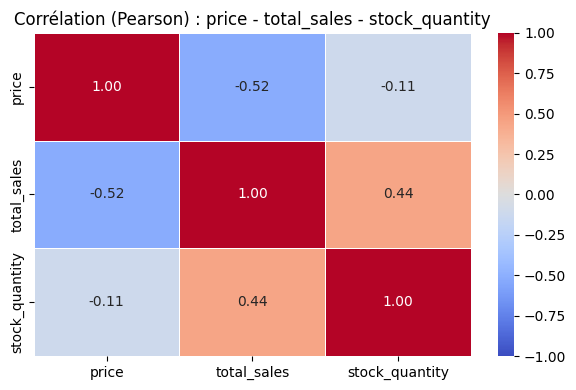

In [135]:
# CORRELATION PEARSON
# ------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) On repart du périmètre cohérent : ventes web disponibles
df_corr = df_final_web[["price", "total_sales", "stock_quantity"]].copy()

# 2) Sécurisation : numérique + gestion des inf/NaN
df_corr = df_corr.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Option : enlever les lignes incomplètes sur ces 3 colonnes
df_corr = df_corr.dropna()

# 3) Matrice de corrélation (Pearson)
print("Matrice de corrélation Pearson")
print("-"*50)
corr = df_corr.corr(method="pearson").round(2)

display(corr)

# 4) Heatmap
print("")
print("Heatmap _ Pearson")
print("-"*50)
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=.5,vmin=-1, vmax=1, center=0,cmap="coolwarm")
plt.title("Corrélation (Pearson) : price - total_sales - stock_quantity")
plt.tight_layout()
plt.show()


In [136]:
# Calcul de la p_value pour chacune des pairs _Corrélation Pearson
# -----------------------------------------------------------------

from scipy.stats import pearsonr
import numpy as np, pandas as pd

print("Pearson bilatéral | H0: ρ=0 (pas de corrélation) | H1: ρ≠0 (corrélation)\n")

cols = ["price","total_sales","stock_quantity"]
df = (df_final_web[cols].apply(pd.to_numeric, errors="coerce")
      .replace([np.inf,-np.inf], np.nan).dropna())

pairs = [(a,b) for i,a in enumerate(cols) for b in cols[i+1:]]
tests = pd.DataFrame([(a,b,*pearsonr(df[a], df[b])) for a,b in pairs],
                     columns=["var_1","var_2","r","p_value"])\
          .assign(signif_5=lambda d: np.where(d.p_value<0.05,"Oui","Non"))\
          .sort_values("p_value")

display(df.corr().round(2))   # matrice des r
display(tests)                # r + p-value + décision


Pearson bilatéral | H0: ρ=0 (pas de corrélation) | H1: ρ≠0 (corrélation)



,price,total_sales,stock_quantity
price,1.00,-0.52,-0.11
total_sales,-0.52,1.00,0.44
stock_quantity,-0.11,0.44,1.00


,var_1,var_2,r,p_value,signif_5
0,price,total_sales,-0.516321,7.810511e-50,Oui
2,total_sales,stock_quantity,0.439254,5.429945e-35,Oui
1,price,stock_quantity,-0.106098,4.567247e-03,Oui


Matrice de corrélation Spearman
--------------------------------------------------


,price,total_sales,stock_quantity
price,1.00,-0.70,-0.57
total_sales,-0.70,1.00,0.76
stock_quantity,-0.57,0.76,1.00



Heatmap _ Spearman
--------------------------------------------------


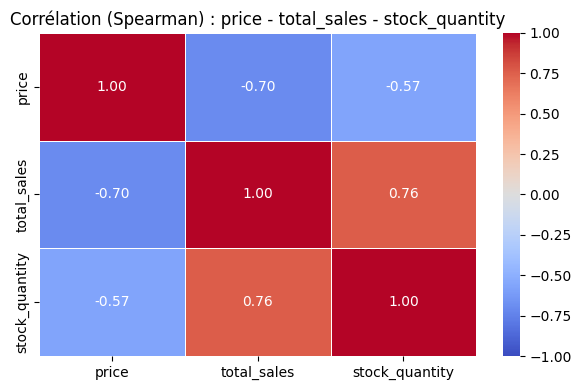

In [143]:
# CORRELATION SPEARMAN
# ------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) On repart du périmètre cohérent : ventes web disponibles
df_corr = df_final_web[["price", "total_sales", "stock_quantity"]].copy()

# 2) Sécurisation : numérique + gestion des inf/NaN
df_corr = df_corr.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Option : enlever les lignes incomplètes sur ces 3 colonnes
df_corr = df_corr.dropna()

# 3) Matrice de corrélation (Spearman)
print("Matrice de corrélation Spearman")
print("-"*50)
corr = df_corr.corr(method="spearman").round(2)

display(corr)

# 4) Heatmap
print("")
print("Heatmap _ Spearman")
print("-"*50)
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=.5,vmin=-1, vmax=1, center=0,cmap="coolwarm")
plt.title("Corrélation (Spearman) : price - total_sales - stock_quantity")
plt.tight_layout()
plt.show()


In [138]:
# Calcul de la p_value pour chacune des pairs _ Corrélation Spearman
# --------------------------------------------------------------------

from scipy.stats import spearmanr
import numpy as np, pandas as pd

print("Spearman bilatéral | H0: ρ=0 (pas de corrélation monotone) | H1: ρ≠0 (corrélation monotone)\n")

cols = ["price","total_sales","stock_quantity"]
df = (df_final_web[cols].apply(pd.to_numeric, errors="coerce")
      .replace([np.inf,-np.inf], np.nan).dropna())

pairs = [(a,b) for i,a in enumerate(cols) for b in cols[i+1:]]
tests = pd.DataFrame([(a,b,*spearmanr(df[a], df[b])) for a,b in pairs],
                     columns=["var_1","var_2","rho","p_value"])\
          .assign(signif_5=lambda d: np.where(d.p_value<0.05,"Oui","Non"))\
          .sort_values("p_value")

display(df.corr(method="spearman").round(2))  # matrice rho
display(tests)                                 # rho + p-value + décision


Spearman bilatéral | H0: ρ=0 (pas de corrélation monotone) | H1: ρ≠0 (corrélation monotone)



,price,total_sales,stock_quantity
price,1.00,-0.70,-0.57
total_sales,-0.70,1.00,0.76
stock_quantity,-0.57,0.76,1.00


,var_1,var_2,rho,p_value,signif_5
2,total_sales,stock_quantity,0.759992,3.497835e-135,Oui
0,price,total_sales,-0.701795,8.066550e-107,Oui
1,price,stock_quantity,-0.571596,4.370606e-63,Oui


In [139]:
#Que peut-on conclure des corrélations ?

## Conclusion des corrélations (Pearson vs Spearman)

Les matrices de corrélation confirment des relations **cohérentes métier**, mais avec une intensité différente selon la mesure utilisée.

### 1) Prix vs Ventes (`price` ↔ `total_sales`)
- Corrélation **négative** : plus le prix augmente, moins on vend en quantité.
- Pearson : **-0,52** (relation linéaire modérée)
- Spearman : **-0,70** (relation monotone plus marquée)

➡️ **Interprétation :** effet “élasticité prix” net, probablement **non linéaire** (les produits chers se vendent moins, mais pas au même rythme à chaque euro supplémentaire).

### 2) Ventes vs Stock (`total_sales` ↔ `stock_quantity`)
- Corrélation **positive** : les produits qui se vendent le plus sont aussi ceux qui présentent davantage de stock.
- Pearson : **+0,44**
- Spearman : **+0,76**

➡️ **Interprétation :** relation monotone forte : les références à forte demande sont **structurellement** plus stockées (logique de disponibilité / best-sellers).

### 3) Prix vs Stock (`price` ↔ `stock_quantity`)
- Corrélation **négative** : plus c’est cher, moins on stocke (en volume).
- Pearson : **-0,11** (faible)
- Spearman : **-0,57** (modérée)

➡️ **Interprétation :** les produits premium semblent stockés plus “finement” (risque d’immobilisation), avec une relation plutôt **non linéaire**.

---

## Quelle mesure privilégier ici ?

Compte tenu d’une distribution **asymétrique** (prix, ventes, stock) et de la présence probable d’**outliers**, **Spearman** est généralement **plus robuste** et plus fidèle à l’idée :  
> “quand l’une augmente, l’autre tend à augmenter/diminuer”, sans exiger une relation linéaire.

- **Pearson** : utile pour mesurer une **linéarité** (mais peut sous-estimer si la relation est non linéaire).
- **Spearman** : préférable pour capter une **tendance monotone** dans des données de catalogue e-commerce.


## Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel

In [140]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.


In [141]:
import pandas as pd

# =========================
# 1) Sauvegardes "data" (PROC_DIR)
# =========================
df_final_web.to_parquet(PROC_DIR / "df_final_web.parquet", index=False)
df_final_web.to_csv(PROC_DIR / "df_final_web.csv", index=False, encoding="utf-8")

print("✅ Sauvegardes OK :")
print(" -", PROC_DIR / "df_final_web.parquet")
print(" -", PROC_DIR / "df_final_web.csv")


# =========================
# 2) Export Excel "livrable" (OUT_DIR)
# =========================
out_xlsx = OUT_DIR / "df_final_web.xlsx"

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    df_final_web.to_excel(writer, sheet_name="df_final_web", index=False)

print("✅ Export Excel OK :")
print(" -", out_xlsx)


✅ Sauvegardes OK :
 - /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/df_final_web.parquet
 - /content/drive/MyDrive/OC_P6_Bottleneck/data_processed/df_final_web.csv
✅ Export Excel OK :
 - /content/drive/MyDrive/OC_P6_Bottleneck/outputs/df_final_web.xlsx
